# BRAIN TUMOR CLASSIFICATION USING MRI IMAGES

The detection and characterization of brain tumors is a major public health challenge. MRI (Magnetic Resonance Imaging) is the primary diagnostic tool for detecting and characterizing brain tumors. The three tumor types in our dataset have distinct characteristics:

- **Glioma**: Primary brain tumor developing from glial cells; often aggressive and requires prompt treatment.
- **Meningioma**: Usually benign tumor arising from the meninges; more common in women.
- **Pituitary tumor**: Tumor of the pituitary gland, usually benign but can affect hormone levels.

## INSTALLATION OF REQUIRED PACKAGES

In [1]:
pip install -q numpy pandas matplotlib seaborn opencv-python scikit-learn tensorflow kagglehub grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

In [3]:
import kagglehub

# Download latest version
path1 = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
path2 = kagglehub.dataset_download("sofienehermi/brain-tumor-balanced")

print("Path to dataset files:", path1)
print("Path to dataset files:", path2)

Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Using Colab cache for faster access to the 'brain-tumor-balanced' dataset.
Path to dataset files: /kaggle/input/brain-tumor-classification-mri
Path to dataset files: /kaggle/input/brain-tumor-balanced


In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## EXPLORATORY DATA ANALYSIS

### DATASET EXPLORATION

In [5]:
BASE_PATH = path1
dataset_info = {
    'Training': defaultdict(int),
    'Testing': defaultdict(int)
}

image_dimensions = {
    'Training': defaultdict(list),
    'Testing': defaultdict(list)
}

for split in ['Training', 'Testing']:
    split_path = os.path.join(BASE_PATH, split)

    if not os.path.exists(split_path):
        continue

    print(f"\n{split}")
    print("-" * 70)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            count = len(images)
            dataset_info[split][class_name] = count

            print(f"  ├─ {class_name:25s}: {count:4d} images")

            sample_size = min(50, count)
            for img_name in images[:sample_size]:
                img_path = os.path.join(class_path, img_name)
                try:
                    img = Image.open(img_path)
                    image_dimensions[split][class_name].append(img.size)
                except:
                    pass

    total = sum(dataset_info[split].values())
    print(f"  └─ {'TOTAL':25s}: {total:4d} images")


Training
----------------------------------------------------------------------
  ├─ no_tumor                 :  395 images
  ├─ pituitary_tumor          :  827 images
  ├─ meningioma_tumor         :  822 images
  ├─ glioma_tumor             :  826 images
  └─ TOTAL                    : 2870 images

Testing
----------------------------------------------------------------------
  ├─ no_tumor                 :  105 images
  ├─ pituitary_tumor          :   74 images
  ├─ meningioma_tumor         :  115 images
  ├─ glioma_tumor             :  100 images
  └─ TOTAL                    :  394 images


In [6]:
import os
from collections import defaultdict

BASE_PATH = path2

dataset_info = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

print("\nDATASET STRUCTURE ANALYSIS (PATH2)")
print("=" * 80)

for task in os.listdir(BASE_PATH):  # binary_classification, multiclass_classification
    task_path = os.path.join(BASE_PATH, task)

    if not os.path.isdir(task_path):
        continue

    print(f"\n{task}")
    print("-" * 80)

    for split in os.listdir(task_path):  # train, test, validation
        split_path = os.path.join(task_path, split)

        if not os.path.isdir(split_path):
            continue

        print(f"\n{split}")
        print("  " + "-" * 60)

        total = 0

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if os.path.isdir(class_path):
                images = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

                count = len(images)
                dataset_info[task][split][class_name] = count
                total += count

                print(f"  ├─ {class_name:15s}: {count:4d} images")

        print(f"  └─ {'TOTAL':15s}: {total:4d} images")


DATASET STRUCTURE ANALYSIS (PATH2)

binary_classification
--------------------------------------------------------------------------------

validation
  ------------------------------------------------------------
  ├─ no_tumor       :   90 images
  ├─ tumor          :   90 images
  └─ TOTAL          :  180 images

test
  ------------------------------------------------------------
  ├─ no_tumor       :  105 images
  ├─ tumor          :  115 images
  └─ TOTAL          :  220 images

train
  ------------------------------------------------------------
  ├─ no_tumor       :  510 images
  ├─ tumor          :  510 images
  └─ TOTAL          : 1020 images

multiclass_classification
--------------------------------------------------------------------------------

validation
  ------------------------------------------------------------
  ├─ pituitary      :  125 images
  ├─ meningioma     :  124 images
  ├─ glioma         :  124 images
  └─ TOTAL          :  373 images

test
  -------------

## DATASETS MERGING

In [7]:
import os
import shutil
import random

path1_train = os.path.join(path1, 'Training')
path1_test = os.path.join(path1, 'Testing')

path2_multi = os.path.join(path2, 'multiclass_classification')

In [8]:
import os
import shutil
import random

path1_train = os.path.join(path1, 'Training')
path1_test = os.path.join(path1, 'Testing')
MERGED_DATASET_ROOT = '/content/merged_brain_tumor_dataset'

# Ensure the root directory for the merged dataset exists
os.makedirs(MERGED_DATASET_ROOT, exist_ok=True)
if not os.path.exists(os.path.join(MERGED_DATASET_ROOT, 'multiclass_classification')) or \
   not os.path.exists(os.path.join(MERGED_DATASET_ROOT, 'binary_classification')):
    print(f"Copying original dataset from '{path2}' to '{MERGED_DATASET_ROOT}'...")
    # Using ignore_patterns to avoid copying directly if shutil.copytree is run multiple times
    shutil.copytree(path2, MERGED_DATASET_ROOT, dirs_exist_ok=True)
    print("Original dataset copied to writable location.")

# Now, path2_multi (and path2_test, etc.) will implicitly refer to the new writable location.
# Update the local path2_multi variable to point to the writable version for this merge.
path2_multi = os.path.join(MERGED_DATASET_ROOT, 'multiclass_classification')

for class_name in os.listdir(path1_train):
    src_class_path = os.path.join(path1_train, class_name)

    # mapping names (important!)
    class_map = {
        "glioma_tumor": "glioma",
        "meningioma_tumor": "meningioma",
        "pituitary_tumor": "pituitary"
    }

    if class_name not in class_map:
        continue

    target_class = class_map[class_name]
    dst_class_path = os.path.join(path2_multi, 'train', target_class) # Now path2_multi is writable

    os.makedirs(dst_class_path, exist_ok=True)

    images = [f for f in os.listdir(src_class_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    for img in images:
        src = os.path.join(src_class_path, img)
        dst = os.path.join(dst_class_path, f"p1_{img}")
        shutil.copy2(src, dst)

print("✅ Training data merged")


Copying original dataset from '/kaggle/input/brain-tumor-balanced' to '/content/merged_brain_tumor_dataset'...
Original dataset copied to writable location.
✅ Training data merged


In [9]:
path2 = MERGED_DATASET_ROOT

In [10]:
split_ratio = 0.5  # 50% test, 50% validation

for class_name in os.listdir(path1_test):
    src_class_path = os.path.join(path1_test, class_name)

    class_map = {
        "glioma_tumor": "glioma",
        "meningioma_tumor": "meningioma",
        "pituitary_tumor": "pituitary"
    }

    if class_name not in class_map:
        continue

    target_class = class_map[class_name]

    images = [f for f in os.listdir(src_class_path)
              if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    random.shuffle(images)

    split_idx = int(len(images) * split_ratio)

    test_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    # Target paths
    test_dst = os.path.join(path2_multi, 'test', target_class)
    val_dst = os.path.join(path2_multi, 'validation', target_class)

    os.makedirs(test_dst, exist_ok=True)
    os.makedirs(val_dst, exist_ok=True)

    # Copy test
    for img in test_imgs:
        shutil.copy2(os.path.join(src_class_path, img),
                     os.path.join(test_dst, f"p1_{img}"))

    # Copy validation
    for img in val_imgs:
        shutil.copy2(os.path.join(src_class_path, img),
                     os.path.join(val_dst, f"p1_{img}"))

print("✅ Testing + Validation merged")

✅ Testing + Validation merged


In [11]:
import os
from collections import defaultdict

BASE_PATH = path2

summary = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

print("\nFINAL MERGED DATASET SUMMARY")
print("=" * 80)

grand_total = 0

for task in os.listdir(BASE_PATH):
    task_path = os.path.join(BASE_PATH, task)

    if not os.path.isdir(task_path):
        continue

    print(f"\n{task.upper()}")
    print("-" * 80)

    task_total = 0

    for split in ['train', 'validation', 'test']:
        split_path = os.path.join(task_path, split)

        if not os.path.exists(split_path):
            continue

        print(f"\n  {split.upper()}")
        print("  " + "-" * 60)

        split_total = 0

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if os.path.isdir(class_path):
                images = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

                count = len(images)
                summary[task][split][class_name] = count
                split_total += count

                print(f"   ├─ {class_name:15s}: {count:5d}")

        print(f"   └─ {'TOTAL':15s}: {split_total:5d}")

        task_total += split_total

    print(f"\n  {task.upper()} TOTAL: {task_total}")
    grand_total += task_total

print("\n" + "=" * 80)
print(f"OVERALL DATASET SIZE: {grand_total}")
print("=" * 80)


FINAL MERGED DATASET SUMMARY

BINARY_CLASSIFICATION
--------------------------------------------------------------------------------

  TRAIN
  ------------------------------------------------------------
   ├─ no_tumor       :   510
   ├─ tumor          :   510
   └─ TOTAL          :  1020

  VALIDATION
  ------------------------------------------------------------
   ├─ no_tumor       :    90
   ├─ tumor          :    90
   └─ TOTAL          :   180

  TEST
  ------------------------------------------------------------
   ├─ no_tumor       :   105
   ├─ tumor          :   115
   └─ TOTAL          :   220

  BINARY_CLASSIFICATION TOTAL: 1420

MULTICLASS_CLASSIFICATION
--------------------------------------------------------------------------------

  TRAIN
  ------------------------------------------------------------
   ├─ meningioma     :  1520
   ├─ glioma         :  1528
   ├─ pituitary      :  1529
   └─ TOTAL          :  4577

  VALIDATION
  ------------------------------------

### IMAGE DIMESNION ANALYSIS

In [12]:
import os
import numpy as np
from PIL import Image
from collections import defaultdict

BASE_PATH = path2

image_dimensions = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

print("\nIMAGE DIMENSION ANALYSIS (MERGED DATASET)")
print("=" * 80)

for task in os.listdir(BASE_PATH):  # binary, multiclass
    task_path = os.path.join(BASE_PATH, task)

    if not os.path.isdir(task_path):
        continue

    print(f"\n{task.upper()}")
    print("-" * 80)

    for split in ['train', 'validation', 'test']:
        split_path = os.path.join(task_path, split)

        if not os.path.exists(split_path):
            continue

        print(f"\n  {split.upper()}")
        print("  " + "-" * 60)

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if not os.path.isdir(class_path):
                continue

            images = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

            # Take sample (avoid slow processing)
            sample_size = min(50, len(images))

            dims = []
            for img_name in images[:sample_size]:
                try:
                    img = Image.open(os.path.join(class_path, img_name))
                    dims.append(img.size)
                except:
                    pass

            if not dims:
                continue

            widths = [d[0] for d in dims]
            heights = [d[1] for d in dims]
            unique_dims = set(dims)

            print(f"\n   {class_name}")

            if len(unique_dims) == 1:
                print(f"      Uniform Size: {dims[0][0]} x {dims[0][1]}")
            else:
                print(f"      Unique Sizes: {len(unique_dims)}")
                print(f"      Width  → Min: {min(widths)}, Max: {max(widths)}, Avg: {np.mean(widths):.1f}")
                print(f"      Height → Min: {min(heights)}, Max: {max(heights)}, Avg: {np.mean(heights):.1f}")
                print(f"      Most Common: {max(set(dims), key=dims.count)}")


IMAGE DIMENSION ANALYSIS (MERGED DATASET)

BINARY_CLASSIFICATION
--------------------------------------------------------------------------------

  TRAIN
  ------------------------------------------------------------

   no_tumor
      Unique Sizes: 28
      Width  → Min: 201, Max: 1024, Avg: 414.0
      Height → Min: 213, Max: 1024, Avg: 416.2
      Most Common: (512, 512)

   tumor
      Unique Sizes: 8
      Width  → Min: 224, Max: 512, Avg: 484.1
      Height → Min: 212, Max: 512, Avg: 486.1
      Most Common: (512, 512)

  VALIDATION
  ------------------------------------------------------------

   no_tumor
      Unique Sizes: 28
      Width  → Min: 200, Max: 724, Avg: 398.7
      Height → Min: 198, Max: 851, Avg: 411.2
      Most Common: (512, 512)

   tumor
      Unique Sizes: 5
      Width  → Min: 215, Max: 721, Avg: 501.5
      Height → Min: 220, Max: 903, Avg: 506.1
      Most Common: (512, 512)

  TEST
  ------------------------------------------------------------

   no_

### CLASS DISTRIBUTION ANALYSIS

In [13]:
import os
import pandas as pd

BASE_PATH = path2

print("\nCLASS DISTRIBUTION ANALYSIS (MERGED DATASET)")
print("=" * 80)

for task in os.listdir(BASE_PATH):  # binary, multiclass
    task_path = os.path.join(BASE_PATH, task)

    if not os.path.isdir(task_path):
        continue

    print(f"\n{task.upper()}")
    print("-" * 80)

    for split in ['train', 'validation', 'test']:
        split_path = os.path.join(task_path, split)

        if not os.path.exists(split_path):
            continue

        counts = {}

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if os.path.isdir(class_path):
                images = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                counts[class_name] = len(images)

        if not counts:
            continue

        total = sum(counts.values())

        df = pd.DataFrame({
            'Class': list(counts.keys()),
            'Count': list(counts.values()),
            'Percentage (%)': [v / total * 100 for v in counts.values()]
        })

        df = df.sort_values('Count', ascending=False)

        print(f"\n {split.upper()} (Total: {total})")
        print(df.to_string(index=False))


CLASS DISTRIBUTION ANALYSIS (MERGED DATASET)

BINARY_CLASSIFICATION
--------------------------------------------------------------------------------

 TRAIN (Total: 1020)
   Class  Count  Percentage (%)
no_tumor    510            50.0
   tumor    510            50.0

 VALIDATION (Total: 180)
   Class  Count  Percentage (%)
no_tumor     90            50.0
   tumor     90            50.0

 TEST (Total: 220)
   Class  Count  Percentage (%)
   tumor    115       52.272727
no_tumor    105       47.727273

MULTICLASS_CLASSIFICATION
--------------------------------------------------------------------------------

 TRAIN (Total: 4577)
     Class  Count  Percentage (%)
 pituitary   1529       33.406161
    glioma   1528       33.384313
meningioma   1520       33.209526

 VALIDATION (Total: 518)
     Class  Count  Percentage (%)
meningioma    182       35.135135
    glioma    174       33.590734
 pituitary    162       31.274131

 TEST (Total: 433)
     Class  Count  Percentage (%)
meningioma  

### VISUALIZATION OF SAMPLES


 BINARY_CLASSIFICATION → TRAIN


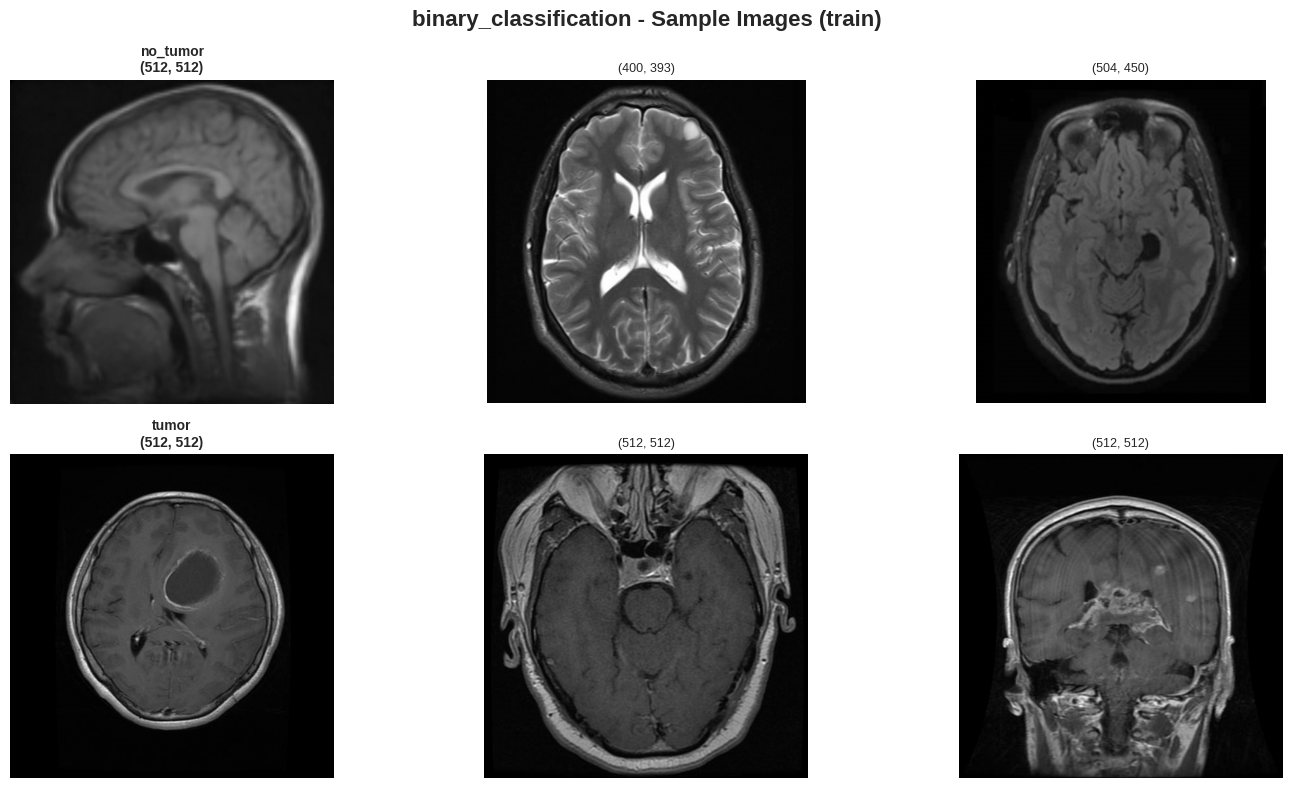


 MULTICLASS_CLASSIFICATION → TRAIN


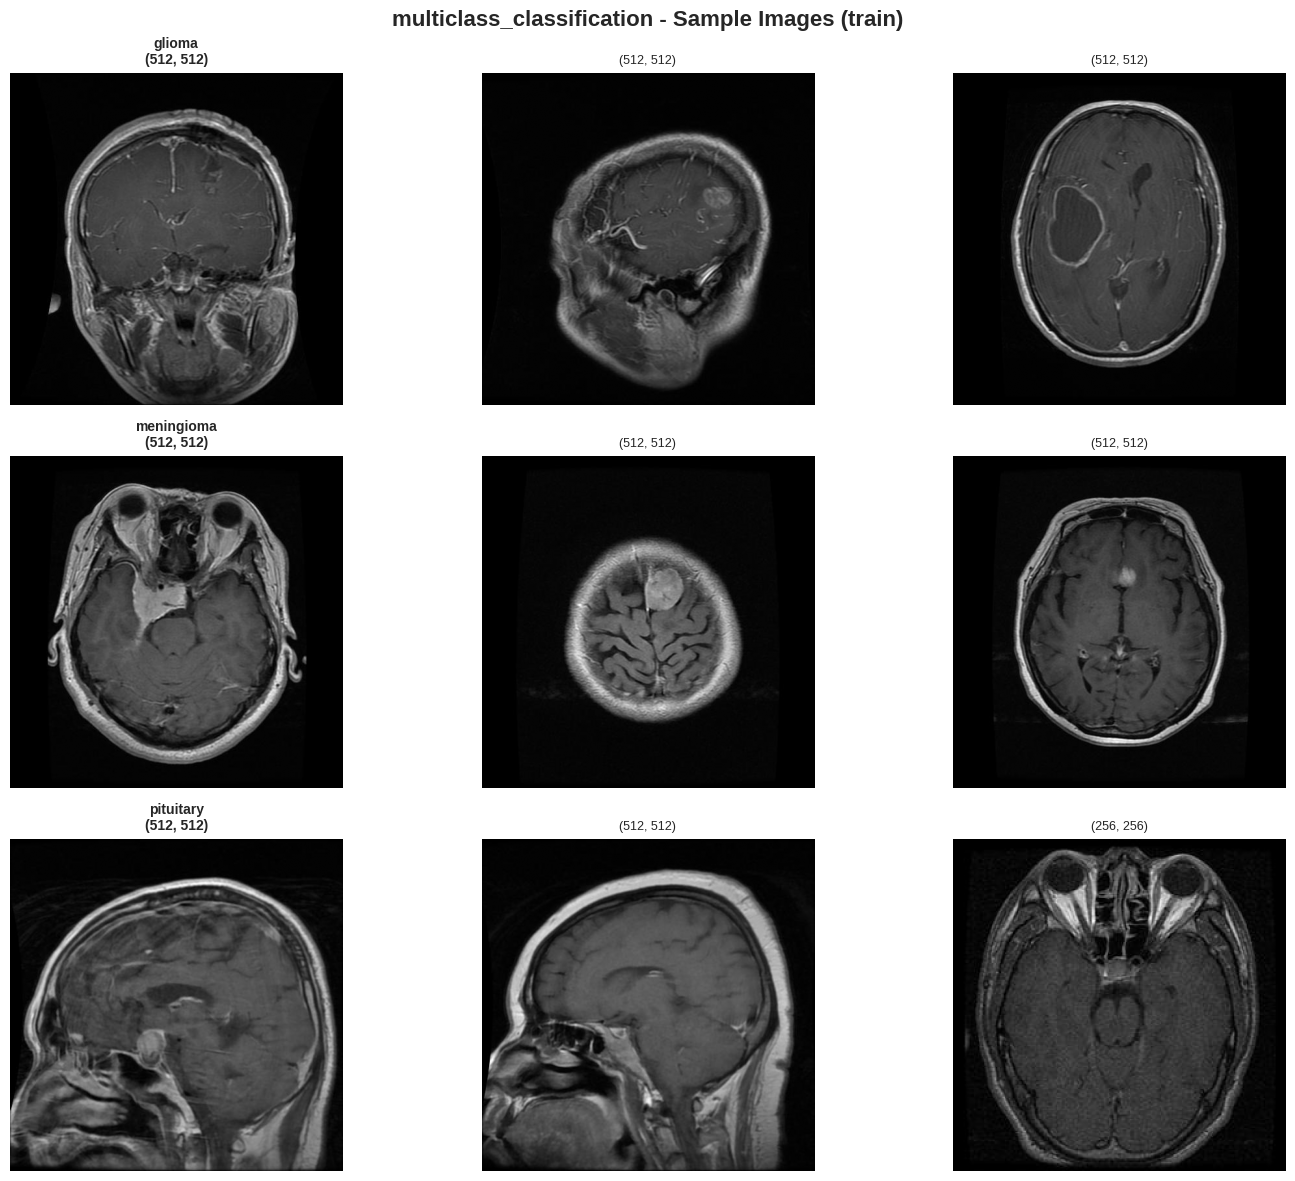

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

BASE_PATH = path2
selected_split = 'train'   # change to 'test' or 'validation' if needed
samples_per_class = 3

for task in os.listdir(BASE_PATH):  # binary + multiclass
    task_path = os.path.join(BASE_PATH, task)

    if not os.path.isdir(task_path):
        continue

    split_path = os.path.join(task_path, selected_split)

    if not os.path.exists(split_path):
        continue

    classes = sorted([d for d in os.listdir(split_path)
                      if os.path.isdir(os.path.join(split_path, d))])

    if len(classes) == 0:
        continue

    print(f"\n {task.upper()} → {selected_split.upper()}")

    fig, axes = plt.subplots(len(classes), samples_per_class,
                             figsize=(15, 4 * len(classes)))

    fig.suptitle(f'{task} - Sample Images ({selected_split})',
                 fontsize=16, fontweight='bold')

    for i, class_name in enumerate(classes):
        class_path = os.path.join(split_path, class_name)

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        if len(images) == 0:
            continue

        samples = np.random.choice(images,
                                   min(samples_per_class, len(images)),
                                   replace=False)

        for j, img_name in enumerate(samples):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            ax = axes[i, j] if len(classes) > 1 else axes[j]

            ax.imshow(img, cmap='gray')
            ax.axis('off')

            if j == 0:
                ax.set_title(f"{class_name}\n{img.shape}",
                             fontsize=10, fontweight='bold')
            else:
                ax.set_title(f"{img.shape}", fontsize=9)

    plt.tight_layout()
    plt.show()

### CLASS DISTRIBUTION CHARTS



📊 Generating distribution plots (Merged Dataset)...

BINARY_CLASSIFICATION


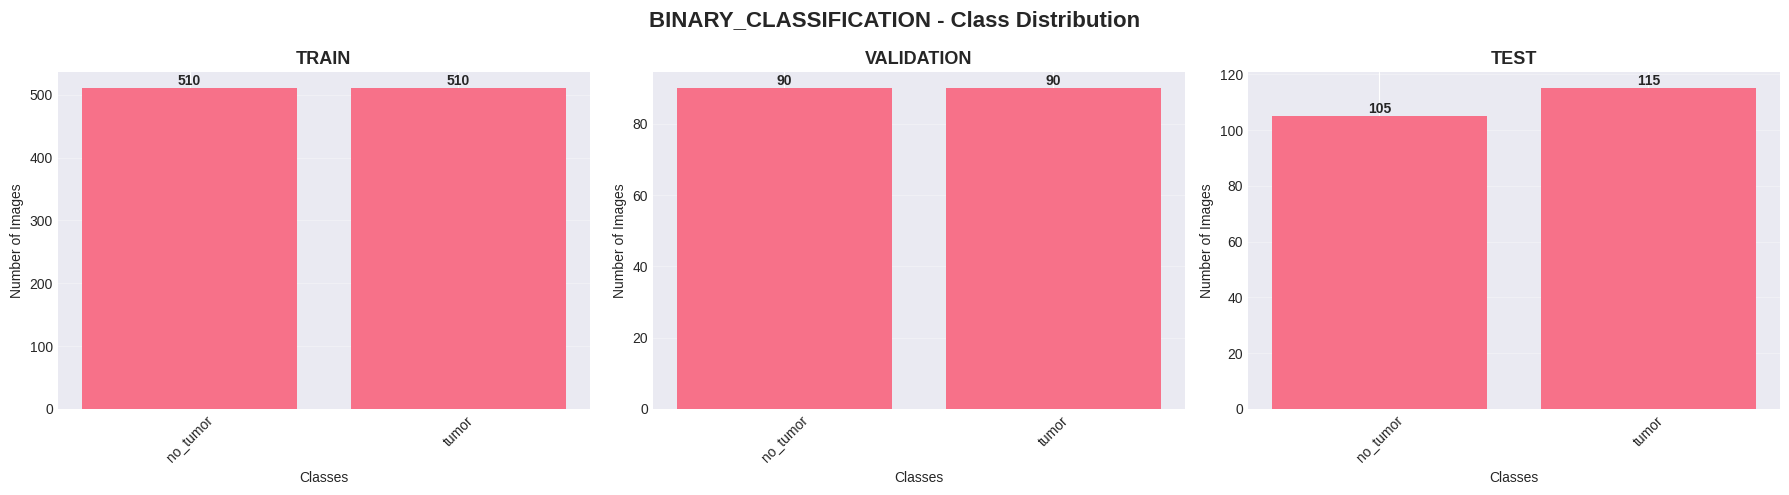


MULTICLASS_CLASSIFICATION


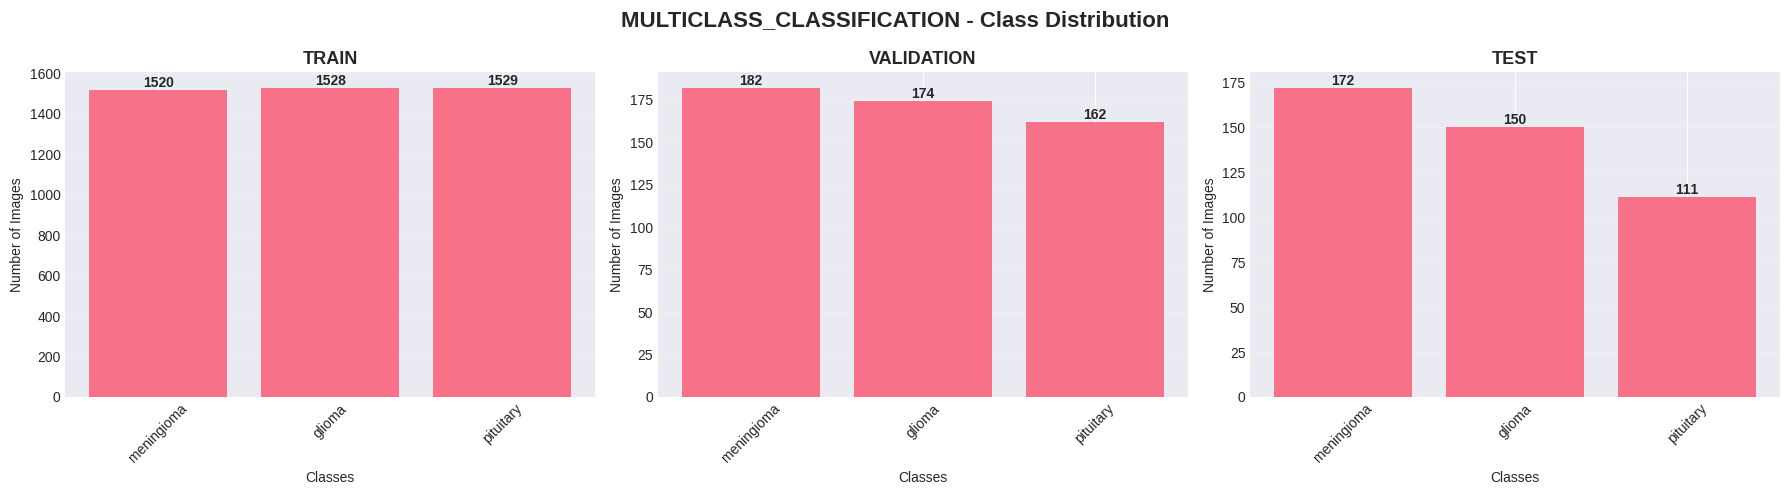

In [16]:
import os
import matplotlib.pyplot as plt

BASE_PATH = path2

print("\n📊 Generating distribution plots (Merged Dataset)...")

for task in os.listdir(BASE_PATH):  # binary + multiclass
    task_path = os.path.join(BASE_PATH, task)

    if not os.path.isdir(task_path):
        continue

    print(f"\n{task.upper()}")

    splits = ['train', 'validation', 'test']

    fig, axes = plt.subplots(1, len(splits), figsize=(18, 5))
    fig.suptitle(f'{task.upper()} - Class Distribution',
                 fontsize=16, fontweight='bold')

    for idx, split in enumerate(splits):
        split_path = os.path.join(task_path, split)

        if not os.path.exists(split_path):
            continue

        counts = {}

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if os.path.isdir(class_path):
                images = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                counts[class_name] = len(images)

        if not counts:
            continue

        classes_list = list(counts.keys())
        values = list(counts.values())

        # Bar chart
        bars = axes[idx].bar(classes_list, values)

        axes[idx].set_title(f'{split.upper()}',
                            fontsize=13, fontweight='bold')
        axes[idx].set_ylabel('Number of Images')
        axes[idx].set_xlabel('Classes')
        axes[idx].tick_params(axis='x', rotation=45)

        # Add values on bars
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2.,
                           height,
                           f'{int(height)}',
                           ha='center', va='bottom',
                           fontweight='bold')

        axes[idx].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

## DATA ANALYSIS


Processing Class: meningioma


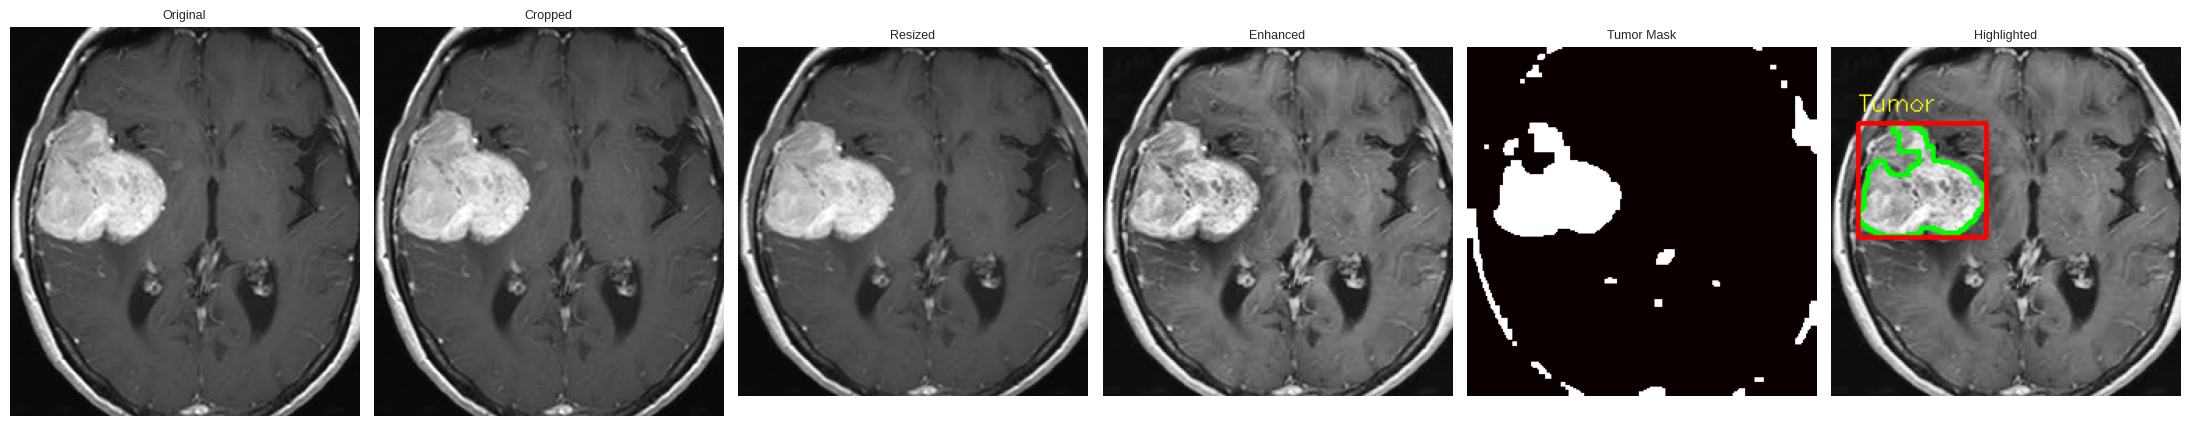

In [43]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

TARGET_SIZE = (224, 224)

# --------------------------------------------------
# 1. Remove black border
# --------------------------------------------------
def remove_black_border(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]


# --------------------------------------------------
# 2. Gentle CLAHE Enhancement
# --------------------------------------------------
def enhance_tumor_contrast(img_rgb):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)

    lab = cv2.merge([l_clahe, a, b])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced


# --------------------------------------------------
# 3. Tumor Isolation - Fixed
# --------------------------------------------------
def isolate_tumor_region(img_rgb):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.uint8)

    h, w = gray.shape

    # Step 1: Build brain mask (exclude pure black background)
    _, brain_mask = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)

    # Step 2: Light erosion — just enough to shave skull edge
    # Use smaller kernel than before (was 15x15 x2 — too aggressive)
    skull_kernel = np.ones((7, 7), np.uint8)
    inner_brain_mask = cv2.erode(brain_mask, skull_kernel, iterations=1)

    # Step 3: Verify inner mask has enough pixels
    brain_pixels = gray[inner_brain_mask > 0]

    # Fallback: if erosion wiped too much, use the original brain mask
    if len(brain_pixels) < 500:
        inner_brain_mask = brain_mask.copy()
        brain_pixels = gray[inner_brain_mask > 0]

    # Step 4: Use 90th percentile — tumor is among the BRIGHTEST regions
    tumor_thresh = np.percentile(brain_pixels, 90)
    _, tumor_candidate_mask = cv2.threshold(
        gray, int(tumor_thresh), 255, cv2.THRESH_BINARY
    )

    # Step 5: Restrict to inside brain
    tumor_mask = cv2.bitwise_and(
        tumor_candidate_mask.astype(np.uint8),
        inner_brain_mask.astype(np.uint8)
    )

    # Step 6: Morphological cleanup — close small holes, remove noise
    close_kernel = np.ones((7, 7), np.uint8)
    open_kernel  = np.ones((3, 3), np.uint8)
    tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_CLOSE, close_kernel)
    tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_OPEN,  open_kernel)

    return tumor_mask.astype(np.uint8)


# --------------------------------------------------
# 4. Highlight Best Tumor Contour
# --------------------------------------------------
def highlight_tumor_on_image(enhanced_img, tumor_mask):
    output = enhanced_img.copy()
    h, w = tumor_mask.shape

    contours, _ = cv2.findContours(
        tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Score each contour: prefer large, compact, centered regions
    cx_img, cy_img = w // 2, h // 2
    best_cnt = None
    best_score = -1

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 200:
            continue

        x, y, cw, ch = cv2.boundingRect(cnt)

        # Skip contours glued to image border
        if x <= 3 or y <= 3 or (x + cw) >= (w - 3) or (y + ch) >= (h - 3):
            continue

        # Compactness: circle-like shapes score higher
        perimeter = cv2.arcLength(cnt, True)
        compactness = (4 * np.pi * area / (perimeter ** 2 + 1e-5))

        # Prefer regions in upper-center (common tumor location in MRIs)
        cx_cnt = x + cw / 2
        cy_cnt = y + ch / 2
        center_dist = np.sqrt((cx_cnt - cx_img)**2 + (cy_cnt - cy_img)**2)
        center_score = 1 / (1 + center_dist / 50)

        score = area * compactness * center_score
        if score > best_score:
            best_score = score
            best_cnt = cnt

    if best_cnt is not None:
        # Green contour outline
        cv2.drawContours(output, [best_cnt], -1, (0, 255, 0), 2)
        # Red bounding box
        x, y, cw, ch = cv2.boundingRect(best_cnt)
        cv2.rectangle(output, (x, y), (x + cw, y + ch), (255, 0, 0), 2)
        # Label
        cv2.putText(output, "Tumor", (x, max(y - 8, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1)
    else:
        print("  [!] No tumor contour found — check mask or percentile threshold")

    return output


# --------------------------------------------------
# 5. Full Preprocessing Pipeline
# --------------------------------------------------
def preprocess_image(img_path, target_size=TARGET_SIZE):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    cropped   = remove_black_border(img)
    resized   = cv2.resize(cropped, target_size)
    enhanced  = enhance_tumor_contrast(resized)
    tumor_mask = isolate_tumor_region(enhanced)
    highlighted = highlight_tumor_on_image(enhanced, tumor_mask)
    normalized  = enhanced.astype(np.float32) / 255.0

    return img, cropped, resized, enhanced, tumor_mask, highlighted, normalized


# --------------------------------------------------
# 6. Visualization
# --------------------------------------------------
def visualize_pipeline(img_path):
    stages = ["Original", "Cropped", "Resized", "Enhanced", "Tumor Mask", "Highlighted"]
    images = preprocess_image(img_path)

    plt.figure(figsize=(22, 5))
    for i, (img, title) in enumerate(zip(images, stages)):
        plt.subplot(1, len(stages), i + 1)
        if title == "Tumor Mask":
            plt.imshow(img, cmap='hot')
        else:
            plt.imshow(img)
        plt.title(title, fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 7. Run on Dataset
# --------------------------------------------------
base_path = os.path.join(path2, 'multiclass_classification', 'test')
#classes = sorted(os.listdir(base_path))
classes = ['meningioma']

for cls in classes:
    cls_path = os.path.join(base_path, cls)
    sample = next(f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.png', '.jpeg')))
    img_path = os.path.join(cls_path, sample)
    print(f"\nProcessing Class: {cls}")
    visualize_pipeline(img_path)

In [49]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# ── Config ────────────────────────────────────────────────────────────────────
TARGET_SIZE = (224, 224)
path3       = "/content/preprocesseddataset"   # ← change if needed

# ── Your existing preprocessing functions (unchanged) ─────────────────────────
def remove_black_border(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if len(img.shape) == 3 else img
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img
    x, y, w, h = cv2.boundingRect(coords)
    return img[y:y+h, x:x+w]

def enhance_tumor_contrast(img_rgb):
    lab    = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe  = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8, 8))
    l_clahe = clahe.apply(l)
    lab    = cv2.merge([l_clahe, a, b])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])
    sharpened  = cv2.filter2D(enhanced, -1, kernel)
    stretched  = cv2.normalize(sharpened, None, 0, 255, cv2.NORM_MINMAX)
    return stretched

def preprocess_and_save(img_path, save_path):
    """
    Reads one image, runs the full pipeline, saves the result.
    Returns True on success, False if the image couldn't be read.
    """
    img = cv2.imread(img_path)
    if img is None:
        return False

    img     = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cropped  = remove_black_border(img)
    resized  = cv2.resize(cropped, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    enhanced = enhance_tumor_contrast(resized)

    # Save as BGR (OpenCV convention)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    cv2.imwrite(save_path, cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))
    return True

# ── Walk the entire path2 tree and mirror it into path3 ───────────────────────
print("="*60)
print("PREPROCESSING ENTIRE DATASET")
print(f"Source : {path2}")
print(f"Output : {path3}")
print("="*60)

total_saved   = 0
total_failed  = 0
class_summary = {}   # { "task/split/class" : count }

# Collect all images first so tqdm can show a meaningful total
all_image_pairs = []   # list of (src_path, dst_path)

for root, dirs, files in os.walk(path2):
    dirs.sort()   # deterministic order
    for fname in sorted(files):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        src = os.path.join(root, fname)
        # Mirror the relative path inside path3
        rel  = os.path.relpath(src, path2)
        dst  = os.path.join(path3, rel)
        all_image_pairs.append((src, dst))

print(f"\n  Total images found : {len(all_image_pairs)}\n")

# ── Process with progress bar ─────────────────────────────────────────────────
for src, dst in tqdm(all_image_pairs, desc="Preprocessing", unit="img"):
    ok = preprocess_and_save(src, dst)

    # Track per-class counts
    # rel path looks like: task/split/class/filename
    parts = os.path.relpath(dst, path3).split(os.sep)
    if len(parts) >= 3:
        key = "/".join(parts[:3])   # e.g. multiclass_classification/train/glioma
        class_summary[key] = class_summary.get(key, 0) + (1 if ok else 0)

    if ok:
        total_saved  += 1
    else:
        total_failed += 1
        print(f"\nSkipped (unreadable): {src}")

# ── Summary report ────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PREPROCESSING COMPLETE")
print("="*60)
print(f"Saved  : {total_saved}")
print(f"Failed : {total_failed}")
print(f"\n  Saved to : {path3}")

print("\nPer-class breakdown:")
print(f"  {'Path':<55} {'Images':>7}")
print("  " + "-"*63)

prev_task = None
for key in sorted(class_summary.keys()):
    task = key.split("/")[0]
    if task != prev_task:
        print()   # blank line between task groups
        prev_task = task
    print(f"  {key:<55} {class_summary[key]:>7}")


PREPROCESSING ENTIRE DATASET
Source : /content/merged_brain_tumor_dataset
Output : /content/preprocesseddataset

  Total images found : 6950



Preprocessing: 100%|██████████| 6950/6950 [00:43<00:00, 159.55img/s]


PREPROCESSING COMPLETE
Saved  : 6950
Failed : 0

  Saved to : /content/preprocesseddataset

Per-class breakdown:
  Path                                                     Images
  ---------------------------------------------------------------

  binary_classification/test/no_tumor                         105
  binary_classification/test/tumor                            115
  binary_classification/train/no_tumor                        510
  binary_classification/train/tumor                           510
  binary_classification/validation/no_tumor                    90
  binary_classification/validation/tumor                       90

  multiclass_classification/test/glioma                       150
  multiclass_classification/test/meningioma                   172
  multiclass_classification/test/pituitary                    111
  multiclass_classification/train/glioma                     1528
  multiclass_classification/train/meningioma                 1520
  multiclass_classificatio

## CONFIGURATION AND DATA LOADING

In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers
import warnings
warnings.filterwarnings('ignore')

In [51]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
BASE_PATH = path3
SEED = 42

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

test_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Binary
train_gen_bin = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'binary_classification/train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED
)

val_gen_bin = test_val_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'binary_classification/validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Multiclass
train_gen_multi = train_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'multiclass_classification/train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen_multi = test_val_datagen.flow_from_directory(
    os.path.join(BASE_PATH, 'multiclass_classification/validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Debug
print("\nClass indices (Multiclass):", train_gen_multi.class_indices)

Found 1020 images belonging to 2 classes.
Found 180 images belonging to 2 classes.
Found 4577 images belonging to 3 classes.
Found 518 images belonging to 3 classes.

Class indices (Multiclass): {'glioma': 0, 'meningioma': 1, 'pituitary': 2}


## EfficientNetB0 Model

### EfficientNetB0 Model Building

In [52]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

def build_efficientnet_model():
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze most layers
    for layer in base_model.layers[:-20]:
        layer.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)   # ✅ IMPORTANT FIX
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    return model

### Binary Classification

In [53]:
model_bin = build_efficientnet_model()

model_bin.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # ✅ lower LR
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [55]:
history_bin = model_bin.fit(
    train_gen_bin,
    validation_data=val_gen_bin,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8127 - loss: 0.4168 - precision: 0.8617 - recall: 0.7451 - val_accuracy: 0.8889 - val_loss: 0.4040 - val_precision: 0.8302 - val_recall: 0.9778
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 394ms/step - accuracy: 0.9167 - loss: 0.2125 - precision: 0.9363 - recall: 0.8941 - val_accuracy: 0.8833 - val_loss: 0.3224 - val_precision: 0.8224 - val_recall: 0.9778
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 400ms/step - accuracy: 0.9363 - loss: 0.1594 - precision: 0.9441 - recall: 0.9275 - val_accuracy: 0.8778 - val_loss: 0.2855 - val_precision: 0.8148 - val_recall: 0.9778
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 395ms/step - accuracy: 0.9608 - loss: 0.1119 - precision: 0.9663 - recall: 0.9549 - val_accuracy: 0.9056 - val_loss: 0.2394 - val_precision: 0.8544 - val_recall: 0.9778
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - accuracy: 0.9647 - loss: 0.1015 - precision: 0.9740 - recall: 0.9549 - val_accuracy: 0.9222 - val_loss: 

In [56]:
import matplotlib.pyplot as plt

def plot_training_history(history, title="Training Evolution"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy Graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#2ecc71', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#e74c3c', marker='s')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Score')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Loss Graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#2ecc71', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#e74c3c', marker='s')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

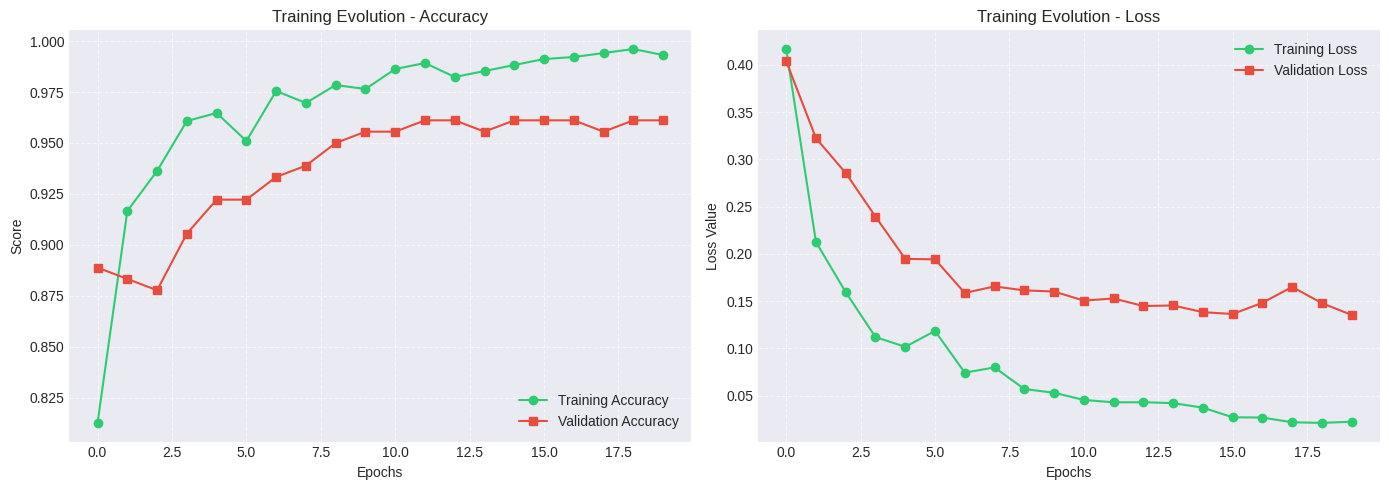

In [57]:
# loss and Accuracy curves
plot_training_history(history_bin, title="Training Evolution")

In [58]:
# Evaluation and Confusion Matrix

def evaluate_and_plot(model, generator, labels, title):
    # Predictions
    preds = model.predict(generator)
    if len(labels) == 2: # Binary case
        y_pred = (preds > 0.5).astype(int).flatten()
    else: # Multi-class case
        y_pred = np.argmax(preds, axis=1)

    y_true = generator.classes

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Classification Report (Precision, Recall, F1)
    print(f"--- Classification Report: {title} ---")
    print(classification_report(y_true, y_pred, target_names=labels))

6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step


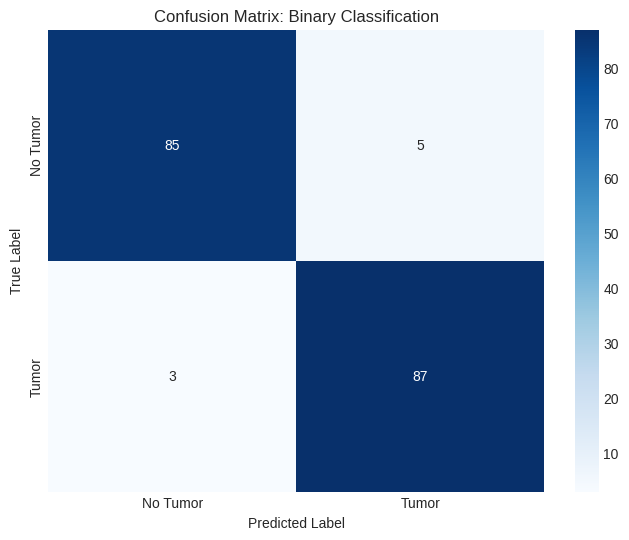

--- Classification Report: Binary Classification ---
              precision    recall  f1-score   support

    No Tumor       0.97      0.94      0.96        90
       Tumor       0.95      0.97      0.96        90

    accuracy                           0.96       180
   macro avg       0.96      0.96      0.96       180
weighted avg       0.96      0.96      0.96       180



In [ ]:
# Display for binary classification
evaluate_and_plot(model_bin, val_gen_bin, ['No Tumor', 'Tumor'], "Binary Classification")

In [59]:
model_bin.save('model_bin.h5')

### Multiclass Classification Model

In [60]:
def build_efficientnet_model(num_classes=3, trainable=False):
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = trainable  # 🔥 control here

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    if num_classes == 1:
        output = layers.Dense(1, activation='sigmoid')(x)
    else:
        output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    return model

In [61]:
model_multi = build_efficientnet_model(num_classes=3, trainable=False)

model_multi.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

history_multi = model_multi.fit(
    train_gen_multi,
    validation_data=val_gen_multi,
    epochs=5
)

Epoch 1/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 109s 607ms/step - accuracy: 0.7844 - loss: 0.6019 - precision_1: 0.7954 - recall_1: 0.7754 - val_accuracy: 0.7625 - val_loss: 0.5404 - val_precision_1: 0.7808 - val_recall_1: 0.7220
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 53s 370ms/step - accuracy: 0.8551 - loss: 0.4014 - precision_1: 0.8598 - recall_1: 0.8506 - val_accuracy: 0.8398 - val_loss: 0.4013 - val_precision_1: 0.8484 - val_recall_1: 0.8320
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 53s 368ms/step - accuracy: 0.8835 - loss: 0.3147 - precision_1: 0.8881 - recall_1: 0.8807 - val_accuracy: 0.8514 - val_loss: 0.4202 - val_precision_1: 0.8541 - val_recall_1: 0.8475
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 55s 383ms/step - accuracy: 0.8975 - loss: 0.2674 - precision_1: 0.9008 - recall_1: 0.8947 - val_accuracy: 0.8842 - val_loss: 0.3927 - val_precision_1: 0.8857 - val_recall_1: 0.8822
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 54s 374ms/step - accuracy: 0.8999 - loss: 0.2547 - precision_1: 0.9027 - recall_

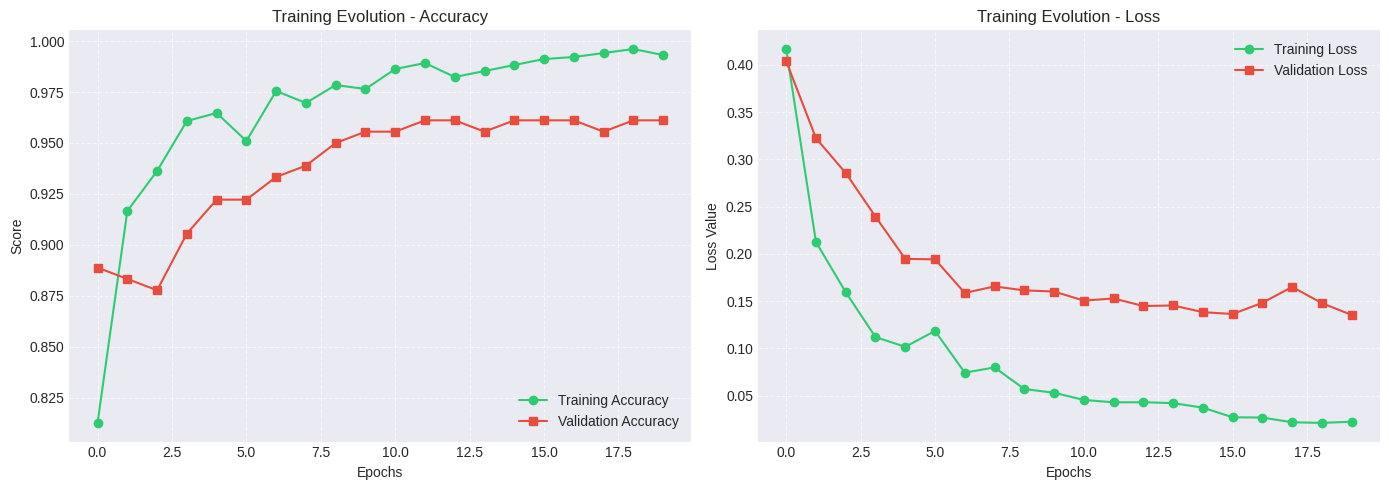

In [62]:
# Loss and Accuracy curves
plot_training_history(history_bin, title="Training Evolution")

17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 486ms/step


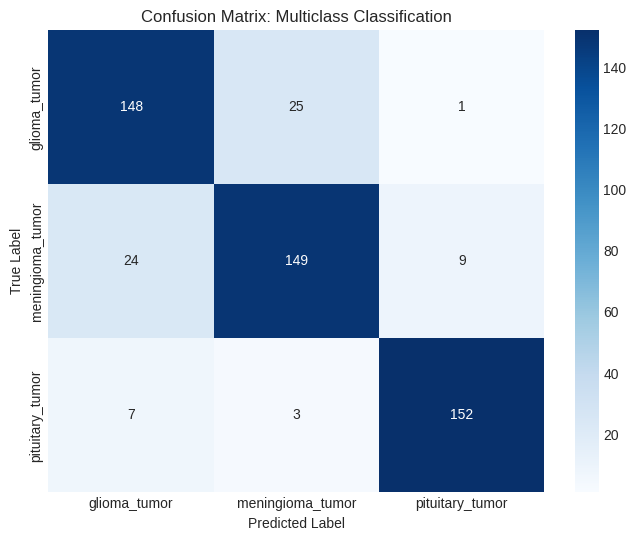

--- Classification Report: Multiclass Classification ---
                  precision    recall  f1-score   support

    glioma_tumor       0.83      0.85      0.84       174
meningioma_tumor       0.84      0.82      0.83       182
 pituitary_tumor       0.94      0.94      0.94       162

        accuracy                           0.87       518
       macro avg       0.87      0.87      0.87       518
    weighted avg       0.87      0.87      0.87       518



In [63]:
# Evaluate the multi-class classification model
evaluate_and_plot(model_multi, val_gen_multi, ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'], "Multiclass Classification")

In [64]:
model_multi.save('model_multi.h5') # Saving the multiclass model

### EfficientNetB0 Model Testing

In [65]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

# Get random image + class info
def get_random_test_image(base_path, classification_type='multiclass_classification'):
    test_dir = os.path.join(base_path, classification_type, 'test')
    image_paths = []

    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)

        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append((os.path.join(class_path, img_name), class_name))

    return random.choice(image_paths) if image_paths else (None, None)

In [66]:
# Final diagnostic pipeline
def diagnostic_pipeline(image_path, true_class, model_bin, model_multi):

    # Load image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # ✅ IMPORTANT: preprocessing
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True Class: {true_class}")
    plt.axis('off')
    plt.show()

    print(f"Image Path: {image_path}")
    print(f"Actual Class: {true_class}")

    # Step 1: Binary prediction
    is_tumor_prob = model_bin.predict(img_array)[0][0]

    print(f"🔍 Tumor Probability: {is_tumor_prob:.4f}")

    if is_tumor_prob < 0.5:
        return "Result: No tumor detected."
    else:
        # Step 2: Multiclass prediction
        type_preds = model_multi.predict(img_array)[0]

        classes_multi = ['Glioma', 'Meningioma', 'Pituitary']
        detected_type = classes_multi[np.argmax(type_preds)]

        return f"Tumor detected → {detected_type} (Confidence: {np.max(type_preds)*100:.2f}%)"


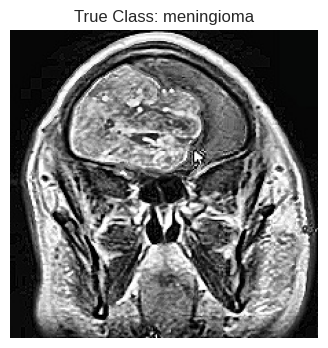

Image Path: /content/preprocesseddataset/multiclass_classification/test/meningioma/image(53).jpg
Actual Class: meningioma


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
🔍 Tumor Probability: 0.9972
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Tumor detected → Meningioma (Confidence: 87.00%)


In [69]:
test_img_path, true_class = get_random_test_image(path3)

if test_img_path:
    binary_model = tf.keras.models.load_model('/content/model_bin.h5')
    multi_model = tf.keras.models.load_model('/content/model_multi.h5')

    result = diagnostic_pipeline(test_img_path, true_class, binary_model, multi_model)
    print(result)

else:
    print("No test images found")

## DenseNet121 Model

### DenseNet121 Model Construction

In [70]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

def build_densenet_model(num_classes=1, trainable=False):
    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = trainable  # control training

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)   # ✅ replaces Flatten
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)  # smaller → less memory
    x = layers.Dropout(0.3)(x)

    if num_classes == 1:
        output = layers.Dense(1, activation='sigmoid')(x)
    else:
        output = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    return model

In [71]:
from tensorflow.keras.applications.densenet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

### Binary Classification

In [72]:
model_bin_dense = build_densenet_model(num_classes=1, trainable=False)

model_bin_dense.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [73]:
history_bin_dense = model_bin_dense.fit(
    train_gen_bin,
    validation_data=val_gen_bin,
    epochs=20
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.7382 - loss: 0.5285 - precision_2: 0.7288 - recall_2: 0.7588 - val_accuracy: 0.7167 - val_loss: 0.6836 - val_precision_2: 0.6489 - val_recall_2: 0.9444
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 405ms/step - accuracy: 0.8471 - loss: 0.3949 - precision_2: 0.8444 - recall_2: 0.8510 - val_accuracy: 0.7944 - val_loss: 0.4716 - val_precision_2: 0.7190 - val_recall_2: 0.9667
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 406ms/step - accuracy: 0.8578 - loss: 0.3420 - precision_2: 0.8600 - recall_2: 0.8549 - val_accuracy: 0.7778 - val_loss: 0.4564 - val_precision_2: 0.7016 - val_recall_2: 0.9667
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 396ms/step - accuracy: 0.8843 - loss: 0.2882 - precision_2: 0.8904 - recall_2: 0.8765 - val_accuracy: 0.8056 - val_loss: 0.4448 - val_precision_2: 0.7311 - val_recall_2: 0.9667
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 397ms/step - accuracy: 0.8882 - loss: 0.2739 - precision_2: 0.9024 - recall_2: 0.8706

In [74]:
model_bin_dense.save('model_bin_dense.h5') # Saving the binary model

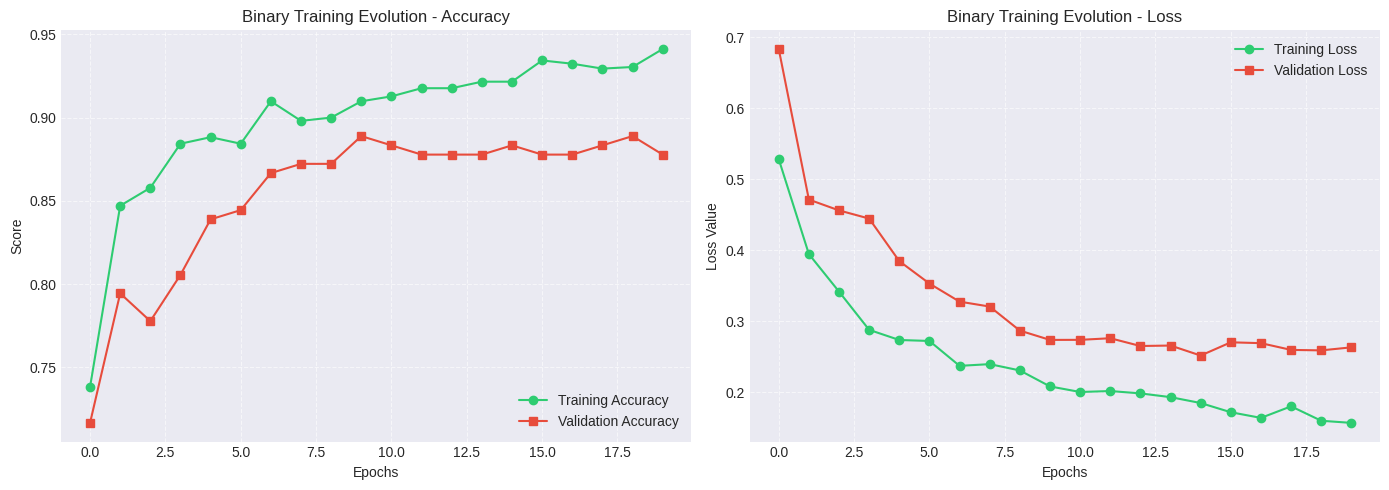

In [75]:
# Loss and Accuracy curves
plot_training_history(history_bin_dense, title="Binary Training Evolution")

6/6 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step


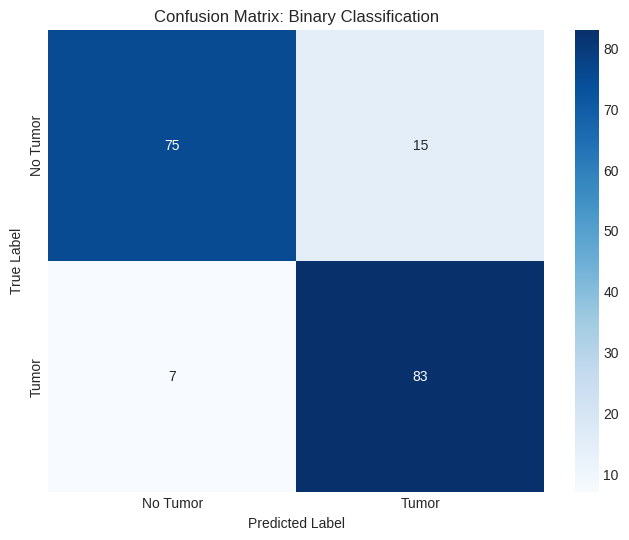

--- Classification Report: Binary Classification ---
              precision    recall  f1-score   support

    No Tumor       0.91      0.83      0.87        90
       Tumor       0.85      0.92      0.88        90

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



In [76]:
# Display for binary
evaluate_and_plot(model_bin_dense, val_gen_bin, ['No Tumor', 'Tumor'], "Binary Classification")

### Multiclass Classfication

In [77]:
model_multi_dense = build_densenet_model(num_classes=3, trainable=False)

model_multi_dense.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
)

In [78]:
history_multi_dense = model_multi_dense.fit(
    train_gen_multi,
    validation_data=val_gen_multi,
    epochs=5
)

Epoch 1/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 117s 648ms/step - accuracy: 0.7675 - loss: 0.5837 - precision_3: 0.7878 - recall_3: 0.7470 - val_accuracy: 0.5618 - val_loss: 1.5419 - val_precision_3: 0.5731 - val_recall_3: 0.5521
Epoch 2/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 56s 389ms/step - accuracy: 0.8243 - loss: 0.4307 - precision_3: 0.8351 - recall_3: 0.8132 - val_accuracy: 0.6873 - val_loss: 1.1503 - val_precision_3: 0.6976 - val_recall_3: 0.6815
Epoch 3/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 58s 400ms/step - accuracy: 0.8584 - loss: 0.3616 - precision_3: 0.8671 - recall_3: 0.8527 - val_accuracy: 0.6641 - val_loss: 1.3868 - val_precision_3: 0.6693 - val_recall_3: 0.6602
Epoch 4/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 56s 390ms/step - accuracy: 0.8672 - loss: 0.3360 - precision_3: 0.8748 - recall_3: 0.8593 - val_accuracy: 0.5251 - val_loss: 2.9443 - val_precision_3: 0.5283 - val_recall_3: 0.5232
Epoch 5/5
144/144 ━━━━━━━━━━━━━━━━━━━━ 57s 399ms/step - accuracy: 0.8785 - loss: 0.3055 - precision_3: 0.8855 - recall_

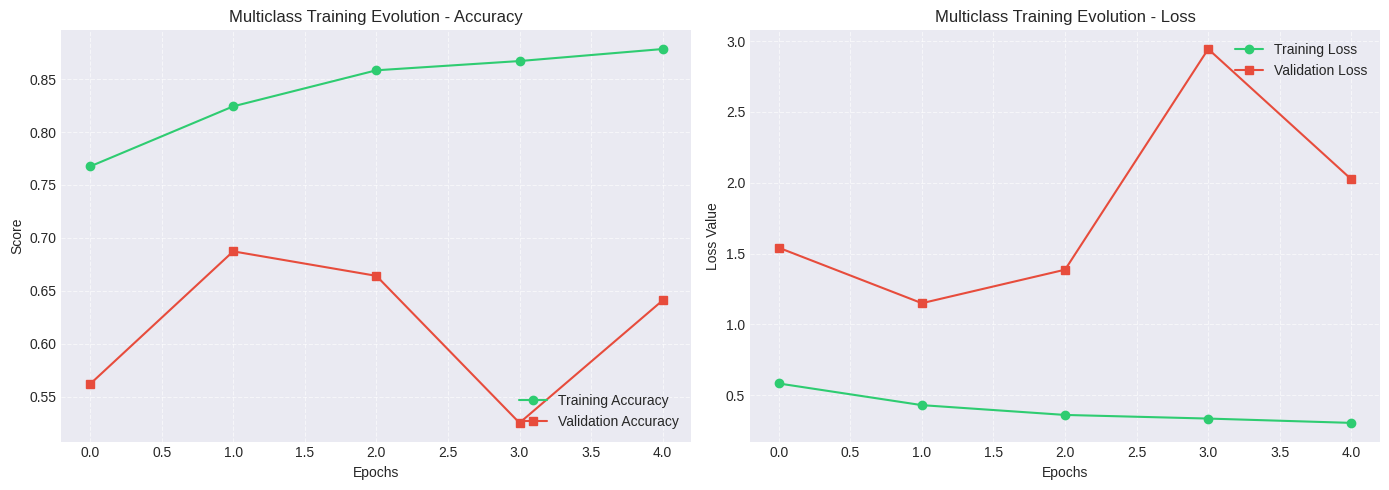

In [79]:
# Loss and Accuracy curves
plot_training_history(history_multi_dense, title="Multiclass Training Evolution")

17/17 ━━━━━━━━━━━━━━━━━━━━ 25s 842ms/step


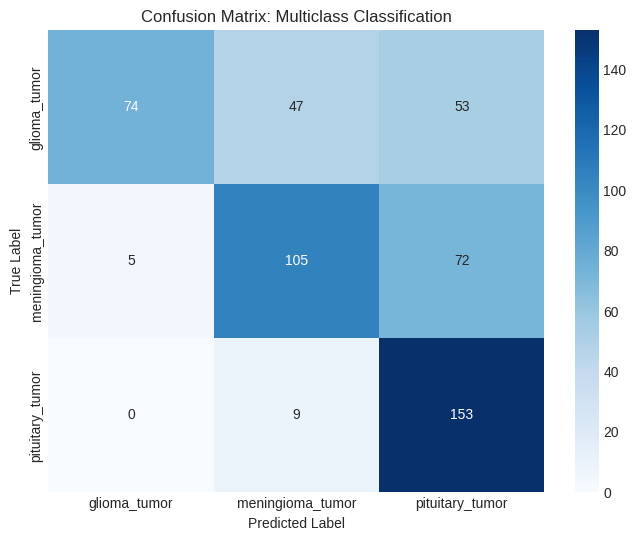

--- Classification Report: Multiclass Classification ---
                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.43      0.58       174
meningioma_tumor       0.65      0.58      0.61       182
 pituitary_tumor       0.55      0.94      0.70       162

        accuracy                           0.64       518
       macro avg       0.71      0.65      0.63       518
    weighted avg       0.72      0.64      0.63       518



In [80]:
# Evaluation and Confusion Matrix
# Display for multiclass
evaluate_and_plot(model_multi_dense, val_gen_multi, ['glioma_tumor', 'meningioma_tumor', 'pituitary_tumor'], "Multiclass Classification")

In [81]:
model_multi_dense.save('model_multi_dense.h5') # Saving the binary model

### DenseNet121 Model Testing

In [82]:
def get_random_test_image(base_path, classification_type='multiclass_classification'):
    test_dir = os.path.join(base_path, classification_type, 'test')
    image_paths = []

    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)

        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append((os.path.join(class_path, img_name), class_name))

    return random.choice(image_paths) if image_paths else (None, None)

Predicting for random image: /content/preprocesseddataset/multiclass_classification/test/pituitary/image(22).jpg


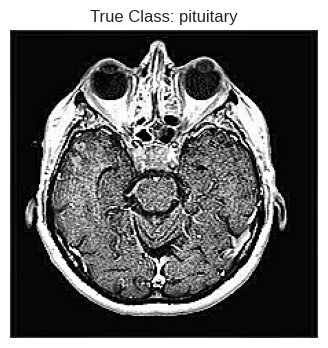

Image Path: /content/preprocesseddataset/multiclass_classification/test/pituitary/image(22).jpg
Actual Class: pituitary
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
🔍 Tumor Probability: 0.0001
Result: No tumor detected.


In [90]:
test_img_path, true_class = get_random_test_image(path3)

if test_img_path:
    binary_model_densenet = model_bin_dense
    multi_model_densenet = model_multi_dense

    print(f"Predicting for random image: {test_img_path}")

    result = diagnostic_pipeline(
        test_img_path,
        true_class,
        binary_model_densenet,
        multi_model_densenet
    )

    print(result)

else:
    print("No test images found to predict.")

## Prototype-Based Neural Network (ProtoPNet)

In [91]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np, os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [92]:
class MRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples, self.labels = [], []
        self.class_names = sorted(os.listdir(root_dir))

        for idx, cls in enumerate(self.class_names):
            cls_path = os.path.join(root_dir, cls)
            if not os.path.isdir(cls_path): continue
            for f in os.listdir(cls_path):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append(os.path.join(cls_path, f))
                    self.labels.append(idx)

        self.transform = transform

    def __len__(self): return len(self.samples)

    def __getitem__(self, i):
        img = Image.open(self.samples[i]).convert('RGB')
        return (self.transform(img) if self.transform else img), self.labels[i]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dir = os.path.join(path3, 'multiclass_classification/train')
val_dir   = os.path.join(path3, 'multiclass_classification/validation')

train_ds = MRIDataset(train_dir, transform)
val_ds   = MRIDataset(val_dir, transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

NUM_CLASSES = len(train_ds.class_names)
NUM_PROTO   = 5
proto_class_names = train_ds.class_names # Define proto_class_names here

In [93]:
class ProtoPNet(nn.Module):
    def __init__(self, num_classes, num_prototypes_per_class=5, proto_dim=128):
        super().__init__()

        self.num_classes = num_classes
        self.num_proto   = num_prototypes_per_class
        self.total_proto = num_classes * num_prototypes_per_class

        # Backbone
        backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.features = nn.Sequential(*list(backbone.children())[:-2])

        feat_dim = 1280

        # Compression
        self.compress = nn.Sequential(
            nn.Conv2d(feat_dim, proto_dim, 1),
            nn.BatchNorm2d(proto_dim),
            nn.ReLU()
        )

        # Prototypes
        self.prototypes = nn.Parameter(
            torch.randn(self.total_proto, proto_dim, 1, 1)
        )

        # Fully connected layer
        self.fc = nn.Linear(self.total_proto, num_classes, bias=False)
        self._init_fc_weights()

    def _init_fc_weights(self):
        w = torch.full((self.num_classes, self.total_proto), -0.5)
        for c in range(self.num_classes):
            start = c * self.num_proto
            w[c, start:start + self.num_proto] = 1.0
        self.fc.weight = nn.Parameter(w)

    def forward(self, x):
        f = self.compress(self.features(x))  # (B, D, H, W)

        # Flatten spatial dimension
        f = f.flatten(2).permute(0, 2, 1)  # (B, HW, D)
        p = self.prototypes.view(self.total_proto, -1)  # (P, D)

        # Compute L2 distance
        distances = torch.cdist(f, p.unsqueeze(0))  # (B, HW, P)

        min_dist = distances.min(dim=1).values  # (B, P)

        # ✅ FIXED similarity
        similarity = -min_dist

        logits = self.fc(similarity)

        return logits, min_dist


In [94]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_proto = ProtoPNet(NUM_CLASSES, NUM_PROTO).to(device)

# Freeze backbone initially
for param in model_proto.features.parameters():
    param.requires_grad = False

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_proto.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 86.0MB/s]


In [95]:
def train_proto(model, train_loader, val_loader, epochs=10):

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            logits, min_dist = model(imgs)

            ce_loss = F.cross_entropy(logits, labels)

            # ✅ Clustering loss
            clust_loss = min_dist.min(dim=1).values.mean()

            # ✅ Separation loss (NEW)
            sep_loss = -min_dist.max(dim=1).values.mean()

            loss = ce_loss + 0.8 * clust_loss + 0.2 * sep_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (logits.argmax(1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()

        train_acc = correct / total * 100

        # ── Validation ──
        model.eval()
        val_correct, val_total = 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits, _ = model(imgs)

                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total * 100

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} "
              f"| Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


In [96]:
train_proto(model_proto, train_loader, val_loader, epochs=10)

Epoch 1/10 | Loss: 5.7391 | Train Acc: 50.27% | Val Acc: 66.02%
Epoch 2/10 | Loss: 4.3161 | Train Acc: 74.50% | Val Acc: 75.10%
Epoch 3/10 | Loss: 3.8194 | Train Acc: 80.86% | Val Acc: 78.19%
Epoch 4/10 | Loss: 3.5219 | Train Acc: 84.60% | Val Acc: 80.50%
Epoch 5/10 | Loss: 3.2773 | Train Acc: 87.31% | Val Acc: 81.47%
Epoch 6/10 | Loss: 3.0832 | Train Acc: 88.09% | Val Acc: 82.82%
Epoch 7/10 | Loss: 2.9737 | Train Acc: 88.79% | Val Acc: 82.43%
Epoch 8/10 | Loss: 2.8955 | Train Acc: 89.29% | Val Acc: 83.59%
Epoch 9/10 | Loss: 2.8196 | Train Acc: 90.28% | Val Acc: 83.98%
Epoch 10/10 | Loss: 2.7442 | Train Acc: 90.54% | Val Acc: 85.52%


              precision    recall  f1-score   support

      glioma       0.93      0.76      0.84       174
  meningioma       0.76      0.92      0.83       182
   pituitary       0.93      0.88      0.90       162

    accuracy                           0.86       518
   macro avg       0.87      0.85      0.86       518
weighted avg       0.87      0.86      0.86       518



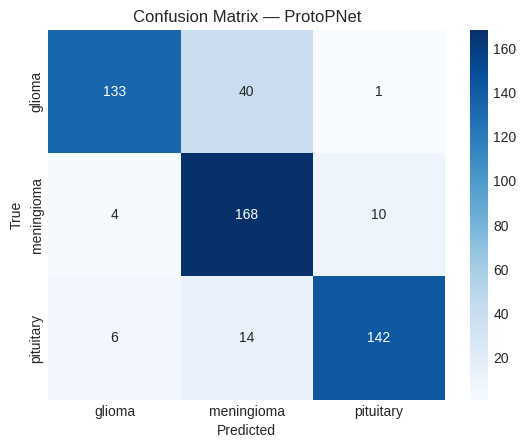

In [97]:
model_proto.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        logits, _ = model_proto(imgs.to(device))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

class_names = train_ds.class_names

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix — ProtoPNet')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

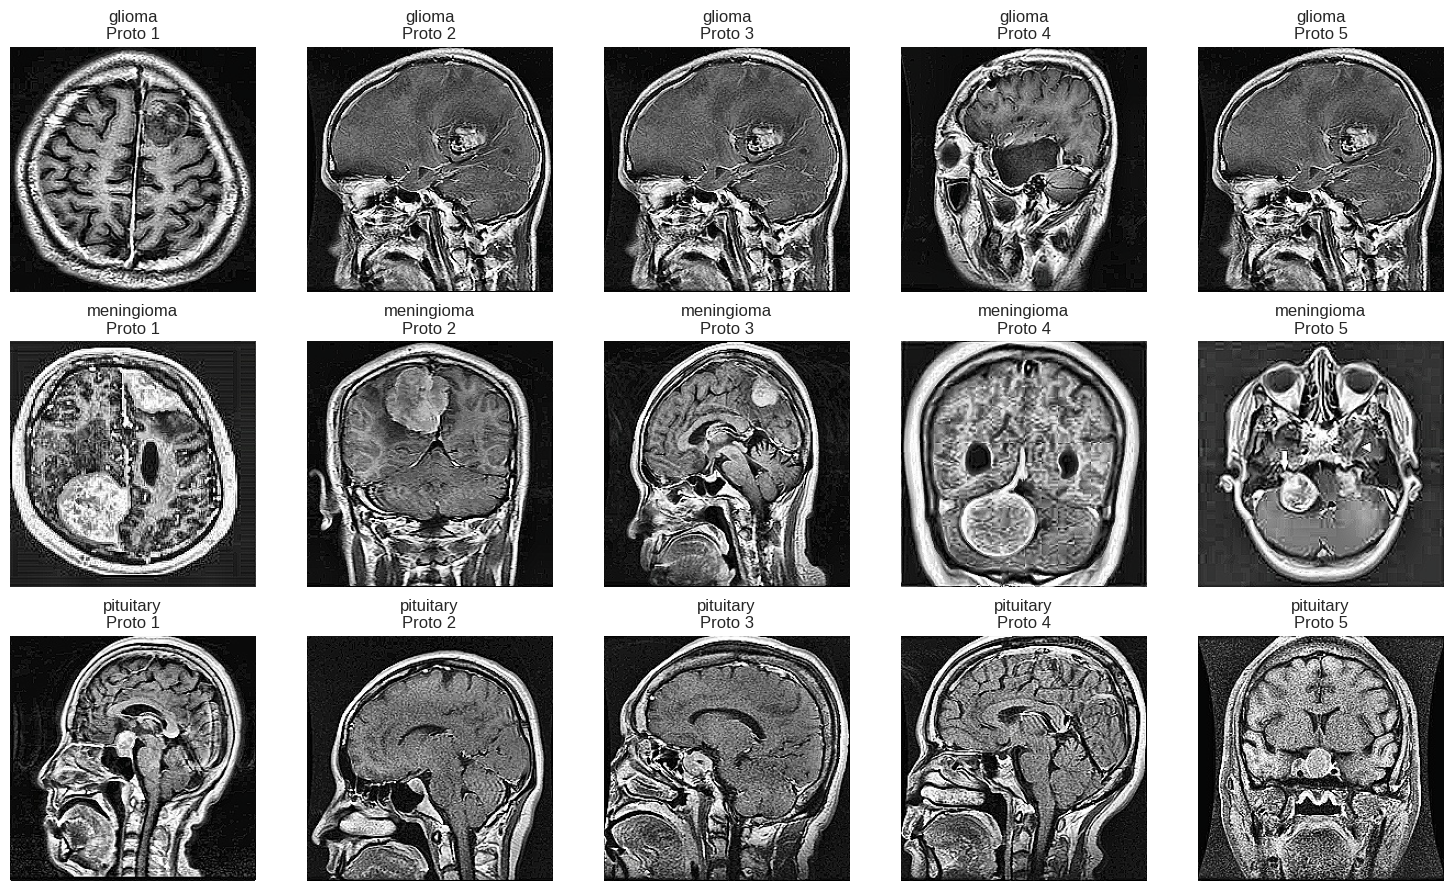

In [98]:
# ── 7. Prototype Visualization ─────────────────────────────────────────
def visualize_prototypes(model, dataset, class_names, device):
    model.eval()

    fig, axes = plt.subplots(len(class_names), model.num_proto,
                             figsize=(model.num_proto * 3, len(class_names) * 3))

    for class_idx, class_name in enumerate(class_names):

        class_imgs = [dataset[i][0] for i in range(len(dataset))
                      if dataset.labels[i] == class_idx][:20]

        if not class_imgs:
            continue

        batch = torch.stack(class_imgs).to(device)

        with torch.no_grad():
            _, min_dist = model(batch)

        for proto_idx in range(model.num_proto):
            p = class_idx * model.num_proto + proto_idx

            best_img_idx = min_dist[:, p].argmin().item()

            img = class_imgs[best_img_idx].permute(1, 2, 0).cpu().numpy()
            img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
            img = np.clip(img, 0, 1)

            axes[class_idx, proto_idx].imshow(img)
            axes[class_idx, proto_idx].axis('off')
            axes[class_idx, proto_idx].set_title(f'{class_name}\nProto {proto_idx+1}')

    plt.tight_layout()
    plt.show()


visualize_prototypes(model_proto, train_ds, class_names, device)

In [99]:
import os

OUTPUT_BASE = '/content/output'  # Define OUTPUT_BASE
os.makedirs(os.path.join(OUTPUT_BASE, 'model'), exist_ok=True)

# Save the trained ProtoPNet model
model_path = os.path.join(OUTPUT_BASE, 'model', 'protopnet_model.pt')
torch.save({
    'num_classes': NUM_CLASSES,
    'num_prototypes': NUM_PROTO,
    'model_state_dict': model_proto.state_dict(),
    'class_names': train_ds.class_names
}, model_path)
print(f"ProtoPNet model saved to {model_path}")

ProtoPNet model saved to /content/output/model/protopnet_model.pt


## FINAL PREDICTION

In [101]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
from torchvision import transforms
from PIL import Image
from collections import Counter
from tensorflow.keras.applications.efficientnet import preprocess_input

In [102]:
def preprocess_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    return img

In [103]:
def preprocess_image_pytorch(image_path, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    img = Image.open(image_path).convert('RGB')
    img = transform(img).unsqueeze(0)
    return img.to(device)

In [104]:
def get_random_test_image(base_path, classification_type='multiclass_classification'):
    test_dir = os.path.join(base_path, classification_type, 'test')
    image_paths = []

    for class_name in os.listdir(test_dir):
        class_path = os.path.join(test_dir, class_name)

        if os.path.isdir(class_path):
            for img_name in os.listdir(class_path):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    image_paths.append((os.path.join(class_path, img_name), class_name))

    return random.choice(image_paths) if image_paths else (None, None)

In [105]:
def combined_diagnostic_pipeline(image_path, true_class, models, proto_model, proto_class_names, device):

    img_array = preprocess_image(image_path)
    results = []

    classes_multi = ['Glioma', 'Meningioma', 'Pituitary']

    # ===== EfficientNet =====
    is_tumor_prob = models['eff_bin'].predict(img_array, verbose=0)[0][0]

    if is_tumor_prob >= 0.5:
        probs = models['eff_multi'].predict(img_array, verbose=0)[0]
        pred = classes_multi[np.argmax(probs)]
        conf = np.max(probs) * 100
    else:
        pred = "No Tumor"
        conf = (1 - is_tumor_prob) * 100

    results.append({'model': 'EfficientNet', 'prediction': pred, 'confidence': conf})

    # ===== DenseNet =====
    is_tumor_prob = models['dense_bin'].predict(img_array, verbose=0)[0][0]

    if is_tumor_prob >= 0.5:
        probs = models['dense_multi'].predict(img_array, verbose=0)[0]
        pred = classes_multi[np.argmax(probs)]
        conf = np.max(probs) * 100
    else:
        pred = "No Tumor"
        conf = (1 - is_tumor_prob) * 100

    results.append({'model': 'DenseNet', 'prediction': pred, 'confidence': conf})

    # ===== ProtoPNet =====
    img_tensor = preprocess_image_pytorch(image_path, device)

    with torch.no_grad():
        output = proto_model(img_tensor)

        if isinstance(output, tuple):
            logits = output[0]
        else:
            logits = output

        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    proto_class = proto_class_names[np.argmax(probs)]
    proto_conf = np.max(probs) * 100

    # Handle No Tumor case
    if proto_conf < 50:
        proto_pred = "No Tumor"
    else:
        proto_pred = proto_class

    results.append({'model': 'ProtoPNet', 'prediction': proto_pred, 'confidence': proto_conf})

    # ===== PRINT ALL RESULTS =====
    print("\n--- Individual Model Predictions ---")
    for r in results:
        print(f"{r['model']}: {r['prediction']} ({r['confidence']:.2f}%)")

    # ===== TRUE VOTING =====
    predictions = [r['prediction'] for r in results]
    vote = Counter(predictions).most_common(1)[0][0]

    filtered = [r for r in results if r['prediction'] == vote]
    best_result = max(filtered, key=lambda x: x['confidence'])

    return best_result

In [106]:
all_models = {
    'eff_bin': model_bin,             # EfficientNet binary
    'eff_multi': model_multi,         # EfficientNet multiclass
    'dense_bin': model_bin_dense,     # DenseNet binary
    'dense_multi': model_multi_dense  # DenseNet multiclass
}


Image Path: /content/preprocesseddataset/multiclass_classification/test/meningioma/image(112).jpg
Actual Class: meningioma

--- Individual Model Predictions ---
EfficientNet: Glioma (98.21%)
DenseNet: Meningioma (99.92%)
ProtoPNet: No Tumor (38.26%)

===== FINAL ENSEMBLE RESULT =====
Prediction: Glioma
Confidence: 98.21%
Model Used: EfficientNet


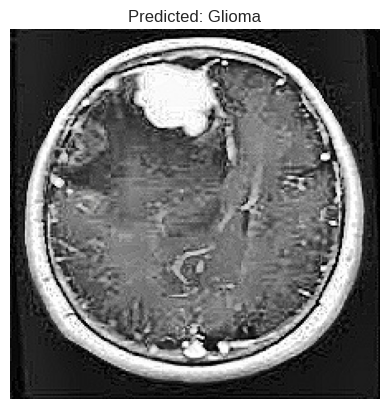

In [132]:
# Load random image
test_img_path, true_class = get_random_test_image(path3)

if test_img_path:
    print(f"\nImage Path: {test_img_path}")
    print(f"Actual Class: {true_class}")

    # Run ensemble
    result = combined_diagnostic_pipeline(
        test_img_path,
        true_class,
        all_models,
        model_proto,
        proto_class_names,
        device
    )

    print("\n===== FINAL ENSEMBLE RESULT =====")
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2f}%")
    print(f"Model Used: {result['model']}")

    # Display image
    img = plt.imread(test_img_path)
    plt.imshow(img)
    plt.title(f"Predicted: {result['prediction']}")
    plt.axis('off')
    plt.show()

else:
    print("No test images found.")

## ACCURACY PRECESSION and RECALL

In [112]:
# ── Helper: safely fetch last value of a metric ──────────────────────────────
def get_last(history_dict, prefix):
    """Returns the last value of the first key matching prefix (training only)."""
    key = next((k for k in history_dict if k.startswith(prefix) and not k.startswith('val_')), None)
    return history_dict[key][-1] if key else None


def print_metrics(label, history_dict):
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")

    acc = get_last(history_dict, 'accuracy')
    if acc is not None:
        print(f"  Accuracy   — Train: {acc:.4f}")

    prec = get_last(history_dict, 'precision')
    if prec is not None:
        print(f"  Precision  — Train: {prec:.4f}")

    rec = get_last(history_dict, 'recall')
    if rec is not None:
        print(f"  Recall     — Train: {rec:.4f}")
    else:
        print(f"  Precision/Recall — Not tracked (add to model.compile metrics to enable)")


# ── EfficientNetB0 ────────────────────────────────────────────────────────────
print_metrics("EfficientNetB0 — Binary Classification",    history_bin.history)
print_metrics("EfficientNetB0 — Multiclass Classification", history_multi.history)

# ── DenseNet121 ───────────────────────────────────────────────────────────────
print_metrics("DenseNet121 — Binary Classification",       history_bin_dense.history)
print_metrics("DenseNet121 — Multiclass Classification",   history_multi_dense.history)


# ── ProtoPNet (Training Metrics Only) ─────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score

model_proto.train()  # training mode

proto_preds, proto_labels = [], []

with torch.no_grad():
    for imgs, labels in train_loader:   # ← CHANGED from val_loader to train_loader
        logits, _ = model_proto(imgs.to(device))
        proto_preds.extend(logits.argmax(1).cpu().numpy())
        proto_labels.extend(labels.numpy())

proto_acc  = accuracy_score(proto_labels, proto_preds)
proto_prec = precision_score(proto_labels, proto_preds, average='macro', zero_division=0)
proto_rec  = recall_score(proto_labels, proto_preds, average='macro', zero_division=0)

print(f"\n{'='*50}")
print(f"  ProtoPNet — Multiclass Classification (Training)")
print(f"{'='*50}")
print(f"  Accuracy   — Train: {proto_acc:.4f}")
print(f"  Precision  — Train: {proto_prec:.4f}  (macro)")
print(f"  Recall     — Train: {proto_rec:.4f}  (macro)")


  EfficientNetB0 — Binary Classification
  Accuracy   — Train: 0.9931
  Precision  — Train: 0.9941
  Recall     — Train: 0.9922

  EfficientNetB0 — Multiclass Classification
  Accuracy   — Train: 0.8999
  Precision  — Train: 0.9027
  Recall     — Train: 0.8975

  DenseNet121 — Binary Classification
  Accuracy   — Train: 0.9412
  Precision  — Train: 0.9482
  Recall     — Train: 0.9333

  DenseNet121 — Multiclass Classification
  Accuracy   — Train: 0.8785
  Precision  — Train: 0.8855
  Recall     — Train: 0.8698

  ProtoPNet — Multiclass Classification (Training)
  Accuracy   — Train: 0.9150
  Precision  — Train: 0.9153  (macro)
  Recall     — Train: 0.9150  (macro)


## Tumor Identification

In [134]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [135]:
def get_brain_mask_hough(img_gray):
    """
    Use Hough Circle detection to find the brain boundary.
    Much more robust than simple thresholding for MRI images with
    varying background intensities (e.g., JPEG-rendered matplotlib panels).
    Falls back to Otsu + flood-fill if Hough fails.
    """
    h, w = img_gray.shape
    blurred = cv2.GaussianBlur(img_gray, (9, 9), 2)

    # Try Hough circle detection with a range of parameters
    circles = cv2.HoughCircles(
        blurred, cv2.HOUGH_GRADIENT, dp=1.2,
        minDist=w // 2,
        param1=50, param2=30,
        minRadius=w // 4,
        maxRadius=w // 2
    )

    if circles is not None:
        # Pick the circle closest to image center
        cx_img, cy_img = w // 2, h // 2
        best = min(circles[0], key=lambda c: (c[0]-cx_img)**2 + (c[1]-cy_img)**2)
        cx, cy, r = int(round(best[0])), int(round(best[1])), int(round(best[2]))
        print(f"  Hough brain circle: center=({cx},{cy}) radius={r}")
        brain_mask = np.zeros((h, w), np.uint8)
        cv2.circle(brain_mask, (cx, cy), r, 255, -1)
        return brain_mask

    # ── Fallback: Otsu + flood-fill from corners ──────────────────────────────
    print("  Hough failed — falling back to Otsu + flood-fill")
    _, otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    bg_fill = otsu.copy()
    for r_corner, c_corner in [(0, 0), (0, w-1), (h-1, 0), (h-1, w-1)]:
        cv2.floodFill(bg_fill, flood_mask, (c_corner, r_corner), 128)
    brain_mask = np.uint8((bg_fill != 128) & (otsu == 255)) * 255
    kern = np.ones((9, 9), np.uint8)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, kern, iterations=4)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN,  kern, iterations=2)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(brain_mask, 8)
    if num_labels >= 2:
        bl = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        brain_mask = np.uint8(labels == bl) * 255
    return brain_mask


In [136]:
def shape_score(contour):
    """
    Returns (score, circularity, solidity).
    High score → compact tumor blob.
    Low score  → arc / crescent / skull-edge artifact.
    """
    area = cv2.contourArea(contour)
    if area == 0:
        return 0, 0, 0
    perimeter   = cv2.arcLength(contour, True)
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    hull_area   = cv2.contourArea(cv2.convexHull(contour))
    solidity    = area / hull_area if hull_area > 0 else 0
    return circularity * solidity, circularity, solidity

In [137]:
def detect_tumor_region(image_path, min_area=800):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # ── STEP 1: Robust brain mask (Hough circle preferred) ────────────────────
    brain_mask = get_brain_mask_hough(img_gray)

    # ── STEP 2: CLAHE inside brain ────────────────────────────────────────────
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img_gray)
    enhanced = cv2.bitwise_and(enhanced, brain_mask)

    # ── STEP 3: Gaussian blur ─────────────────────────────────────────────────
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    # ── STEP 4: Adaptive k selection ─────────────────────────────────────────
    brain_pixels = blurred[brain_mask == 255]
    mean_val     = brain_pixels.mean()
    std_val      = brain_pixels.std()

    if std_val >= 55:
        k_values = [1.8, 1.5, 1.2, 1.0, 0.8]
    elif std_val >= 45:
        k_values = [1.5, 1.2, 1.0, 0.8, 0.6]
    else:
        k_values = [1.2, 1.0, 0.8, 0.6, 0.4]

    print(f"  Brain mean={mean_val:.1f}  std={std_val:.1f}  trying k values: {k_values}")

    best_contour = None
    used_k       = None

    for k in k_values:
        bright_thresh  = int(np.clip(mean_val + k * std_val, 0, 255))
        _, bright_mask = cv2.threshold(blurred, bright_thresh, 255, cv2.THRESH_BINARY)
        bright_mask    = cv2.bitwise_and(bright_mask, brain_mask)

        k_close = np.ones((7, 7), np.uint8)
        k_open  = np.ones((5, 5), np.uint8)
        cleaned = cv2.morphologyEx(bright_mask, cv2.MORPH_CLOSE, k_close, iterations=2)
        cleaned = cv2.morphologyEx(cleaned,     cv2.MORPH_OPEN,  k_open,  iterations=2)

        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        brain_area   = np.sum(brain_mask == 255)

        # ── KEY FIX: filter by area fraction AND shape ────────────────────────
        # circularity >= 0.30  →  reject thin arcs / skull-edge stripes
        # solidity    >= 0.50  →  reject crescent-shaped artifacts
        candidates = []
        for c in contours:
            area = cv2.contourArea(c)
            if area < min_area:
                continue
            ratio = area / brain_area
            if not (0.01 <= ratio <= 0.40):   # 1 % – 40 % of brain area
                continue
            score, circ, solid = shape_score(c)
            if circ < 0.30 or solid < 0.50:
                print(f"    k={k:.1f} | rejected arc: area={area:.0f} "
                      f"circ={circ:.2f} solid={solid:.2f}")
                continue
            candidates.append((area, score, c))
            print(f"    k={k:.1f} | kept blob: area={area:.0f} "
                  f"circ={circ:.2f} solid={solid:.2f}")

        if candidates:
            # Pick the LARGEST qualifying blob (= main tumor mass)
            candidates.sort(key=lambda x: -x[0])
            best_contour = candidates[0][2]
            used_k       = k
            print(f" Accepted at k={used_k}")
            break
        else:
            print(f"    k={k:.1f} | no valid blobs after shape filtering")

    if best_contour is None:
        print("  ⚠ Could not isolate tumor — all k values rejected.")
        return img_rgb, [], None, np.zeros_like(img_gray), brain_mask

    # ── STEP 5: Tumor mask ────────────────────────────────────────────────────
    tumor_mask = np.zeros_like(img_gray)
    cv2.drawContours(tumor_mask, [best_contour], -1, 255, -1)

    # ── STEP 6: Bounding box ──────────────────────────────────────────────────
    rx, ry, rw, rh = cv2.boundingRect(best_contour)

    return img_rgb, [best_contour], (rx, ry, rw, rh), tumor_mask, brain_mask

In [138]:
def measure_tumor_size(contours, pixel_spacing_mm=0.5):
    all_pts = np.vstack(contours)
    _, _, bbox_w, bbox_h = cv2.boundingRect(all_pts)
    bb_length_px = max(bbox_w, bbox_h)
    bb_width_px  = min(bbox_w, bbox_h)

    if len(all_pts) >= 5:
        (ex, ey), (ellipse_w, ellipse_h), angle = cv2.fitEllipse(all_pts)
        el_length_px = max(ellipse_w, ellipse_h)
        el_width_px  = min(ellipse_w, ellipse_h)
    else:
        ex, ey, angle = None, None, 0
        el_length_px, el_width_px = bb_length_px, bb_width_px

    return {
        "bbox_length_px"   : bb_length_px,
        "bbox_width_px"    : bb_width_px,
        "ellipse_length_px": el_length_px,
        "ellipse_width_px" : el_width_px,
        "bbox_length_mm"   : bb_length_px  * pixel_spacing_mm,
        "bbox_width_mm"    : bb_width_px   * pixel_spacing_mm,
        "ellipse_length_mm": el_length_px  * pixel_spacing_mm,
        "ellipse_width_mm" : el_width_px   * pixel_spacing_mm,
        "ellipse_center"   : (int(ex), int(ey)) if ex is not None else None,
        "ellipse_axes"     : (int(el_length_px / 2), int(el_width_px / 2)),
        "ellipse_angle"    : angle,
    }



  Hough brain circle: center=(111,111) radius=94
  Brain mean=133.1  std=45.8  trying k values: [1.5, 1.2, 1.0, 0.8, 0.6]
    k=1.5 | kept blob: area=1317 circ=0.78 solid=0.95
  ✅ Accepted at k=1.5


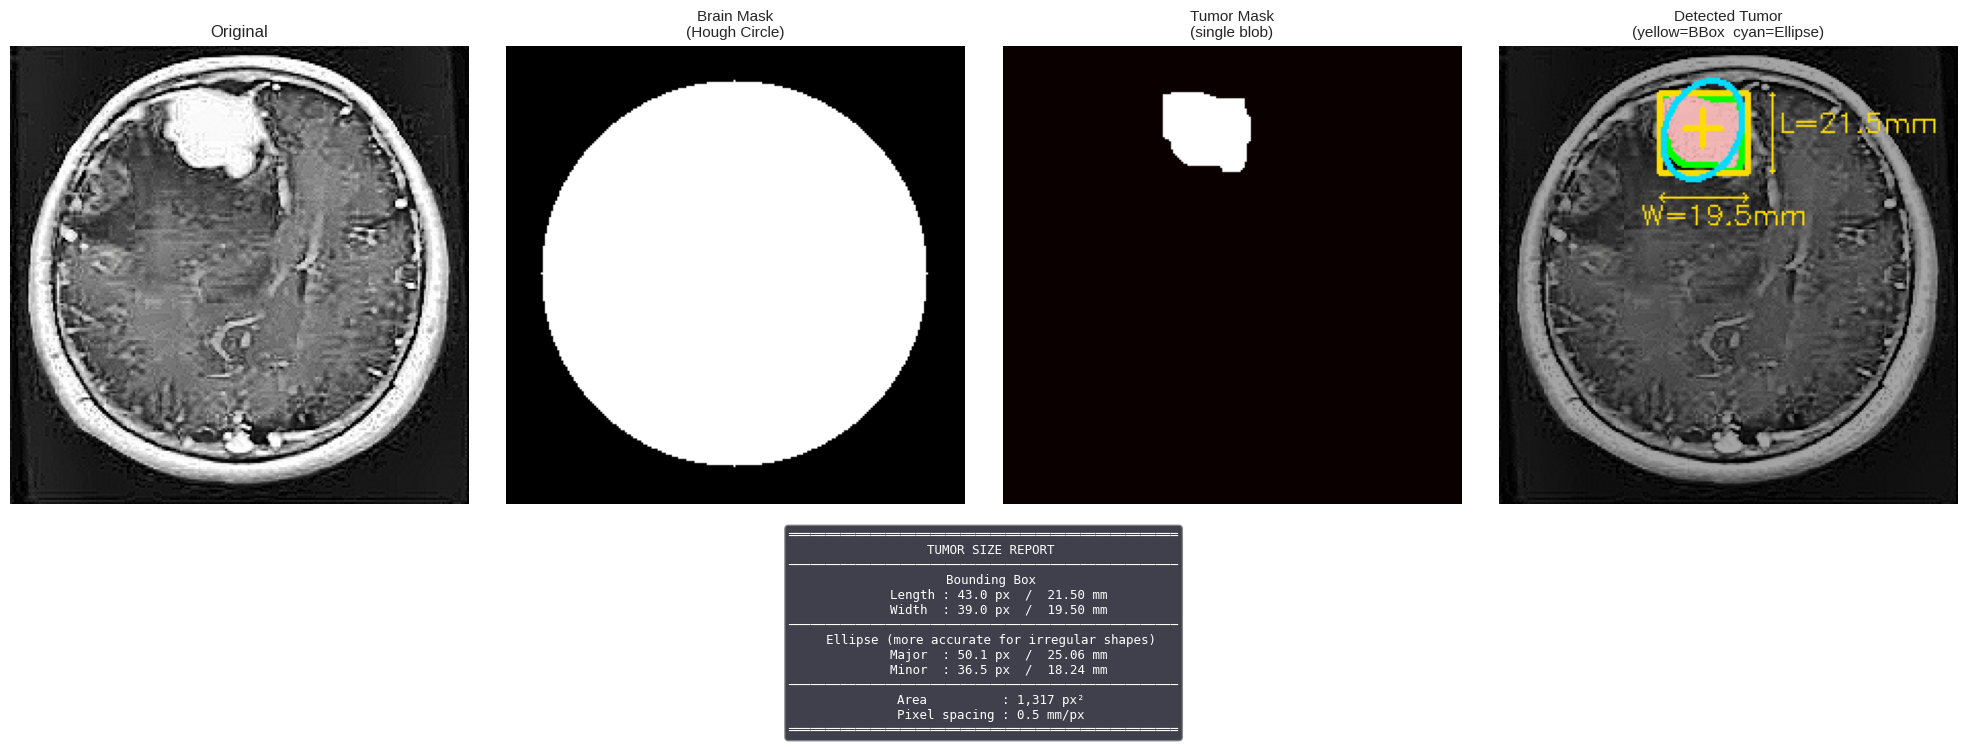

════════════════════════════════════════════════════
  TUMOR SIZE REPORT
────────────────────────────────────────────────────
  Bounding Box
    Length : 43.0 px  /  21.50 mm
    Width  : 39.0 px  /  19.50 mm
────────────────────────────────────────────────────
  Ellipse (more accurate for irregular shapes)
    Major  : 50.1 px  /  25.06 mm
    Minor  : 36.5 px  /  18.24 mm
────────────────────────────────────────────────────
  Area          : 1,317 px²
  Pixel spacing : 0.5 mm/px
════════════════════════════════════════════════════

✓ Saved → tumor_detection_result.png


In [139]:
def visualize_tumor(image_path, pixel_spacing_mm=0.5):

    img_rgb, contours, bbox, tumor_mask, brain_mask = detect_tumor_region(image_path)

    if not contours:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_rgb);                 axes[0].set_title("Original");   axes[0].axis('off')
        axes[1].imshow(brain_mask, cmap='gray'); axes[1].set_title("Brain Mask"); axes[1].axis('off')
        fig.suptitle("No Tumor Detected", fontsize=14, color='red')
        plt.tight_layout(); plt.show()
        return

    x, y, w, h = bbox
    total_area  = int(cv2.contourArea(contours[0]))
    sizes       = measure_tumor_size(contours, pixel_spacing_mm)

    # ── Overlay ───────────────────────────────────────────────────────────────
    overlay   = img_rgb.copy()
    red_layer = np.zeros_like(img_rgb)
    red_layer[tumor_mask == 255] = [220, 50, 50]
    overlay   = cv2.addWeighted(overlay, 0.65, red_layer, 0.35, 0)

    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)
    cv2.rectangle(overlay, (x, y), (x + w, y + h), (255, 220, 0), 2)

    if sizes["ellipse_center"] is not None:
        cv2.ellipse(overlay,
                    sizes["ellipse_center"],
                    sizes["ellipse_axes"],
                    sizes["ellipse_angle"], 0, 360,
                    (0, 220, 255), 2)

    M = cv2.moments(tumor_mask)
    if M["m00"] > 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        cv2.drawMarker(overlay, (cx, cy), (255, 220, 0), cv2.MARKER_CROSS, 18, 2)

    h_img, w_img = img_rgb.shape[:2]
    if y + h + 30 < h_img:
        cv2.arrowedLine(overlay, (x, y+h+12), (x+w, y+h+12), (255,220,0), 1, tipLength=0.05)
        cv2.arrowedLine(overlay, (x+w, y+h+12), (x, y+h+12), (255,220,0), 1, tipLength=0.05)
        cv2.putText(overlay, f"W={sizes['bbox_width_mm']:.1f}mm",
                    (x+w//2-30, y+h+25), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,220,0), 1)
    if x + w + 60 < w_img:
        cv2.arrowedLine(overlay, (x+w+12, y), (x+w+12, y+h), (255,220,0), 1, tipLength=0.05)
        cv2.arrowedLine(overlay, (x+w+12, y+h), (x+w+12, y), (255,220,0), 1, tipLength=0.05)
        cv2.putText(overlay, f"L={sizes['bbox_length_mm']:.1f}mm",
                    (x+w+15, y+h//2), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,220,0), 1)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img_rgb);                axes[0].set_title("Original",         fontsize=12); axes[0].axis('off')
    axes[1].imshow(brain_mask, cmap='gray'); axes[1].set_title("Brain Mask\n(Hough Circle)", fontsize=11); axes[1].axis('off')
    axes[2].imshow(tumor_mask, cmap='hot');  axes[2].set_title("Tumor Mask\n(single blob)",  fontsize=11); axes[2].axis('off')
    axes[3].imshow(overlay);                axes[3].set_title("Detected Tumor\n(yellow=BBox  cyan=Ellipse)", fontsize=11); axes[3].axis('off')

    stats_text = (
        f"{'═'*52}\n"
        f"  TUMOR SIZE REPORT\n"
        f"{'─'*52}\n"
        f"  Bounding Box\n"
        f"    Length : {sizes['bbox_length_px']:.1f} px  /  {sizes['bbox_length_mm']:.2f} mm\n"
        f"    Width  : {sizes['bbox_width_px']:.1f} px  /  {sizes['bbox_width_mm']:.2f} mm\n"
        f"{'─'*52}\n"
        f"  Ellipse (more accurate for irregular shapes)\n"
        f"    Major  : {sizes['ellipse_length_px']:.1f} px  /  {sizes['ellipse_length_mm']:.2f} mm\n"
        f"    Minor  : {sizes['ellipse_width_px']:.1f} px  /  {sizes['ellipse_width_mm']:.2f} mm\n"
        f"{'─'*52}\n"
        f"  Area          : {total_area:,} px²\n"
        f"  Pixel spacing : {pixel_spacing_mm} mm/px\n"
        f"{'═'*52}"
    )
    fig.text(0.5, -0.02, stats_text, ha='center', va='top', fontsize=9,
             family='monospace',
             bbox=dict(boxstyle='round', facecolor='#1e1e2e', alpha=0.85, edgecolor='gray'),
             color='white')

    plt.tight_layout()
    plt.savefig("tumor_detection_result.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(stats_text)
    print(f"\n✓ Saved → tumor_detection_result.png")
visualize_tumor(test_img_path, pixel_spacing_mm=0.5)